# Sleep Health & Lifestyle Analysis

**Goal:** find out which lifestyle and health factors are linked to sleep quality and to sleep disorders.

**Data:** a sleep health and lifestyle dataset of 374 people (age, occupation, sleep duration and quality, stress, activity, steps, BMI, blood pressure, heart rate, sleep disorder).

**How to run in Colab:** choose *Runtime > Run all*. When the upload cell appears, select your CSV file (`Sleep_health_and_lifestyle_dataset.csv`).

**Contents**
1. Setup
2. Load and inspect the raw data
3. Clean the data and build new columns
4. Exploratory analysis: 9 charts, each answering a business question
5. Summary tables
6. Statistical tests: which findings are real, and does the gender gap survive?


## 1. Setup
Libraries, a consistent colour palette, and two small helper functions used by every chart.

In [ ]:
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from matplotlib.patches import Patch

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

OUT = "charts"          # charts are also saved here as PNG files (handy for your README)
os.makedirs(OUT, exist_ok=True)

# Palette: one colour per series, fixed order. Text always uses ink colours, never series colours.
SURFACE = "#fcfcfb"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASE = "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RED, MID = "#e34948", "#f0efec"      # diverging pair (negative, neutral midpoint)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2, "axes.edgecolor": BASE,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "font.family": "sans-serif", "font.size": 10, "axes.titlesize": 11,
})

In [ ]:
# ---- helper functions used by the charts below ----
def lum(hex_colour):
    r, g, b = [c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4 for c in to_rgb(hex_colour)]
    return 0.2126 * r + 0.7152 * g + 0.0722 * b


def text_on(fill):
    """White or dark text, whichever is easier to read on the given fill colour."""
    def contrast(a, b):
        hi, lo = max(lum(a), lum(b)), min(lum(a), lum(b))
        return (hi + 0.05) / (lo + 0.05)
    return "#ffffff" if contrast("#ffffff", fill) >= contrast(INK, fill) else INK


def style_axes(ax, grid="y"):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_color(BASE)
    ax.spines["bottom"].set_color(BASE)
    ax.grid(axis=grid, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0, labelsize=9)


def finish(fig, name, title, subtitle):
    """Add a title and subtitle, save the chart as PNG, and show it in the notebook."""
    h = fig.get_figheight()
    fig.text(0.01, 1 - 0.12 / h, title, ha="left", va="top", fontsize=14, fontweight="bold", color=INK)
    fig.text(0.01, 1 - 0.45 / h, subtitle, ha="left", va="top", fontsize=9.5, color=INK2)
    fig.tight_layout(rect=[0, 0, 1, 1 - 0.85 / h])
    fig.savefig(f"{OUT}/{name}.png", dpi=160)
    plt.show()


def line_panel(ax, x_labels, y, colour, ylabel, fmt="{:.1f}"):
    """Line with round markers; only the first and last points get a value label."""
    xs = np.arange(len(x_labels))
    ax.plot(xs, y, color=colour, linewidth=2, solid_capstyle="round", solid_joinstyle="round")
    ax.plot(xs, y, "o", color=colour, markersize=8, markeredgecolor=SURFACE, markeredgewidth=2)
    for i in (0, len(xs) - 1):
        ax.annotate(fmt.format(y[i]), (xs[i], y[i]), textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=9, color=INK)
    ax.set_xticks(xs)
    ax.set_xticklabels(x_labels)
    pad = (max(y) - min(y)) * 0.25 + 0.05
    ax.set_ylim(min(y) - pad, max(y) + pad * 1.4)
    ax.set_ylabel(ylabel)
    style_axes(ax)

## 2. Load and inspect the raw data
In Colab a file picker appears. Running locally, put the CSV next to the notebook.

`keep_default_na=False` matters here: the sleep disorder value **"None"** means *no disorder*, and pandas would otherwise treat it as a missing value.

In [ ]:
RAW = "Sleep_health_and_lifestyle_dataset.csv"

try:
    from google.colab import files
    if not os.path.exists(RAW):
        print("Choose your sleep dataset CSV file:")
        uploaded = files.upload()
        RAW = next(iter(uploaded))
except ImportError:
    pass  # running outside Colab: the CSV just needs to be in the same folder

df_raw = pd.read_csv(RAW, keep_default_na=False, na_values=[""])
print("Shape:", df_raw.shape)
df_raw.head()

Choose your sleep dataset CSV file:


Saving Sleep_health_and_lifestyle_dataset.csv to Sleep_health_and_lifestyle_dataset.csv
Shape: (374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
print("Missing values in total:", int(df_raw.isna().sum().sum()))
print("Fully duplicated rows (including Person ID):", int(df_raw.duplicated().sum()))

no_id = [c for c in df_raw.columns if c.strip().lower() != "person id"]
print("Rows identical to another row, ignoring Person ID:", int(df_raw.duplicated(subset=no_id).sum()))

print()
for col in ["Gender", "BMI Category", "Sleep Disorder", "Occupation"]:
    print(df_raw[col].value_counts().to_string(), "\n")
df_raw.dtypes

Missing values in total: 0
Fully duplicated rows (including Person ID): 0
Rows identical to another row, ignoring Person ID: 242

Gender
Male      189
Female    185 

BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10 

Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77 

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Scientist                4
Software Engineer        4
Sales Representative     2
Manager                  1 



,0
Person ID,int64
Gender,object
Age,int64
Occupation,object
Sleep Duration,float64
Quality of Sleep,int64
Physical Activity Level,int64
Stress Level,int64
BMI Category,object
Blood Pressure,object


**What this tells us**
- No missing values, but the labels need tidying: the BMI column may contain both "Normal" and "Normal Weight" (same thing), and "Sales Representative" and "Salesperson" are one job.
- **Many rows repeat.** A large share of the 374 rows are identical to another row except for the ID. This dataset looks synthetic, so relationships in it will look cleaner than real-world data. Every result below should be treated as *illustrative*, not as a claim about the real population. Say this in your README; recruiters notice.

## 3. Clean the data and build new columns
Cleaning steps:
1. Standardise column names (`Sleep Duration` becomes `sleep_duration`).
2. Merge duplicate labels (`Normal Weight` into `Normal`, `Sales Representative` into `Salesperson`).
3. Split blood pressure `126/83` into two numeric columns.

New columns for analysis: age group, sleep category, activity group, blood pressure category, and a yes/no disorder flag.

In [ ]:
df = df_raw.copy()

# 1. tidy column names (drops bracketed notes like "(hours)", lower-cases, uses underscores)
df.columns = (
    df.columns.str.replace(r"\(.*?\)", "", regex=True)
    .str.strip().str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True).str.strip("_")
)

# 2. fix category labels
df["bmi_category"] = df["bmi_category"].str.strip().replace({"Normal Weight": "Normal"})
df["sleep_disorder"] = df["sleep_disorder"].str.strip().replace({"": "None"}).fillna("None")
df["gender"] = df["gender"].str.strip().str.title()
df["occupation"] = df["occupation"].str.strip().replace({"Sales Representative": "Salesperson"})

# 3. split blood pressure "126/83" into systolic and diastolic numbers
bp = df["blood_pressure"].str.split("/", expand=True).astype(int)
df["systolic"], df["diastolic"] = bp[0], bp[1]

# 4. new columns
df["age_group"] = pd.cut(df["age"], bins=[0, 29, 39, 49, 120], labels=["20s", "30s", "40s", "50+"])
df["sleep_category"] = pd.cut(df["sleep_duration"], bins=[0, 6, 8, 24],
                              labels=["Short (<6h)", "Healthy (6-8h)", "Long (>8h)"], right=False)


def tertile_groups(s):
    """Low / Medium / High using the 33rd and 67th percentile cut-points.
    People with exactly the same value always land in the same group (so group sizes can be uneven)."""
    q1, q2 = s.quantile([1 / 3, 2 / 3])
    return pd.cut(s, [-np.inf, q1, q2, np.inf], labels=["Low", "Medium", "High"])


df["activity_group"] = tertile_groups(df["physical_activity_level"])


def bp_category(row):
    s, d = row["systolic"], row["diastolic"]
    if s >= 140 or d >= 90:
        return "High"
    if s >= 130 or d >= 80:
        return "Elevated"
    return "Normal"


df["bp_category"] = df.apply(bp_category, axis=1)
df["has_disorder"] = (df["sleep_disorder"] != "None").astype(int)

# sanity checks: stop with a clear error if something is off
assert df["quality_of_sleep"].between(1, 10).all(), "Sleep quality outside 1-10"
assert df["stress_level"].between(1, 10).all(), "Stress level outside 1-10"
assert df["blood_pressure"].str.contains("/").all(), "Unexpected blood pressure format"

df.to_csv("sleep_clean.csv", index=False)   # in Colab: files.download("sleep_clean.csv") to keep a copy
print("Clean data:", df.shape)
df.head()

Clean data: (374, 20)


,person_id,gender,age,occupation,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,blood_pressure,heart_rate,daily_steps,sleep_disorder,systolic,diastolic,age_group,sleep_category,activity_group,bp_category,has_disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,126,83,20s,Healthy (6-8h),Low,Elevated,0
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80,20s,Healthy (6-8h),Medium,Elevated,0
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80,20s,Healthy (6-8h),Medium,Elevated,0
3,4,Male,28,Salesperson,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90,20s,Short (<6h),Low,High,1
4,5,Male,28,Salesperson,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90,20s,Short (<6h),Low,High,1


In [ ]:
# Quick look at the new columns and at group sizes (small groups need careful wording later)
print(df["sleep_disorder"].value_counts().to_string(), "\n")
print(df["bmi_category"].value_counts().to_string(), "\n")
print(df["age_group"].value_counts().sort_index().to_string(), "\n")
print(df["sleep_category"].value_counts().to_string())

sleep_disorder
None           219
Sleep Apnea     78
Insomnia        77 

bmi_category
Normal        216
Overweight    148
Obese          10 

age_group
20s     19
30s    142
40s    117
50+     96 

sleep_category
Healthy (6-8h)    297
Long (>8h)         71
Short (<6h)         6


## 4. Exploratory analysis
Each chart answers one question. Colours are used consistently: blue for a single measure, and fixed blue / orange / aqua when comparing groups.

In [ ]:
# Shared settings for the charts
DISORDER_ORDER = ["None", "Insomnia", "Sleep Apnea"]
DISORDER_LABEL = {"None": "No disorder", "Insomnia": "Insomnia", "Sleep Apnea": "Sleep apnea"}
AGE_ORDER = [a for a in ["20s", "30s", "40s", "50+"] if a in set(df["age_group"].astype(str))]
ACT_ORDER = ["Low", "Medium", "High"]
BMI_ORDER = [b for b in ["Underweight", "Normal", "Overweight", "Obese"] if b in set(df["bmi_category"])]

### 4.1 How much, and how well, do people sleep?

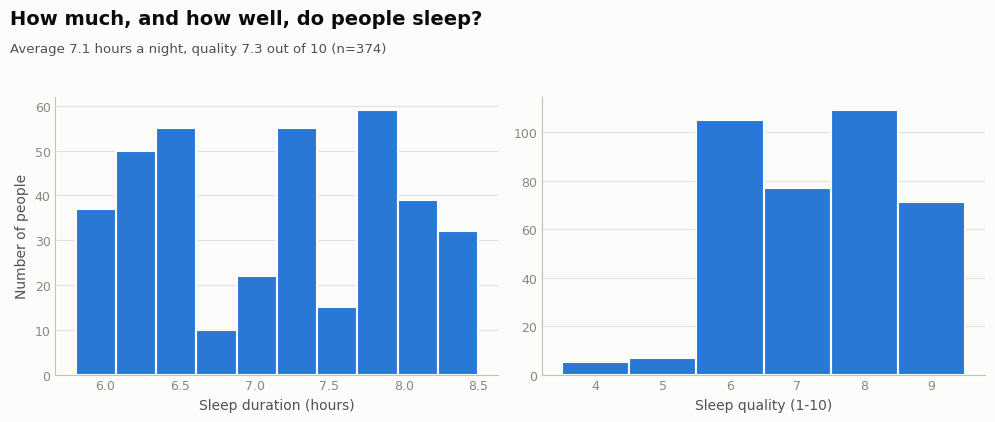

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))

ax = axes[0]
ax.hist(df["sleep_duration"], bins=10, color=BLUE, edgecolor=SURFACE, linewidth=1.5)
ax.set_xlabel("Sleep duration (hours)")
ax.set_ylabel("Number of people")
style_axes(ax)

ax = axes[1]
q = df["quality_of_sleep"]
ax.hist(q, bins=np.arange(q.min() - 0.5, q.max() + 1.5, 1), color=BLUE, edgecolor=SURFACE, linewidth=1.5)
ax.set_xlabel("Sleep quality (1-10)")
ax.set_xticks(range(int(q.min()), int(q.max()) + 1))
style_axes(ax)

finish(fig, "01_sleep_distributions", "How much, and how well, do people sleep?",
       f"Average {df['sleep_duration'].mean():.1f} hours a night, quality {q.mean():.1f} out of 10 (n={len(df)})")

**Finding:** people sleep 7.1 hours on average (range 5.8 to 8.5) and rate their sleep 7.3 out of 10 (range 4 to 9). Nobody sleeps under 5.8 hours, so this sample has no extreme short sleepers.

### 4.2 How common are sleep disorders?

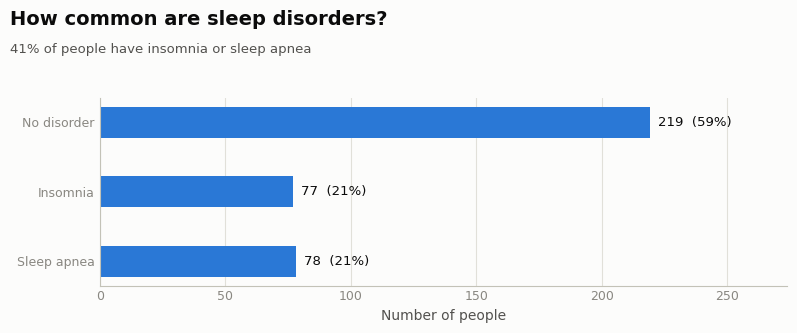

In [ ]:
counts = df["sleep_disorder"].value_counts().reindex(DISORDER_ORDER).fillna(0)

fig, ax = plt.subplots(figsize=(8, 3.4))
ypos = np.arange(len(counts))
ax.barh(ypos, counts.values, height=0.45, color=BLUE)
for y, v in zip(ypos, counts.values):
    ax.text(v + counts.max() * 0.015, y, f"{int(v)}  ({v / counts.sum():.0%})", va="center", fontsize=9.5, color=INK)
ax.set_yticks(ypos)
ax.set_yticklabels([DISORDER_LABEL[c] for c in counts.index])
ax.invert_yaxis()
ax.set_xlim(0, counts.max() * 1.25)
ax.set_xlabel("Number of people")
style_axes(ax, grid="x")

finish(fig, "02_sleep_disorder_share", "How common are sleep disorders?",
       f"{counts[['Insomnia', 'Sleep Apnea']].sum() / counts.sum():.0%} of people have insomnia or sleep apnea")

**Finding:** 219 people (59%) have no sleep disorder; 77 have insomnia and 78 have sleep apnea, so 41% have one. The two disorders are almost equally common, which gives us a balanced target for the prediction step later.

### 4.3 Does stress go with worse sleep?

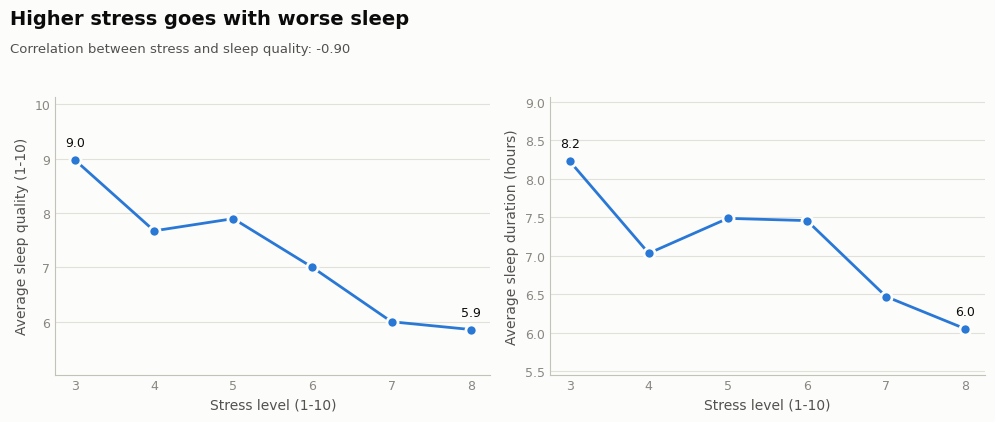

In [ ]:
by_stress = df.groupby("stress_level")[["quality_of_sleep", "sleep_duration"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
line_panel(axes[0], by_stress.index.astype(int), by_stress["quality_of_sleep"].values, BLUE,
           "Average sleep quality (1-10)")
line_panel(axes[1], by_stress.index.astype(int), by_stress["sleep_duration"].values, BLUE,
           "Average sleep duration (hours)")
for ax in axes:
    ax.set_xlabel("Stress level (1-10)")

finish(fig, "03_stress_vs_sleep", "Higher stress goes with worse sleep",
       f"Correlation between stress and sleep quality: {df['stress_level'].corr(df['quality_of_sleep']):.2f}")

**Finding:** the strongest relationship in the data. Average sleep quality drops from 9.0 at stress level 3 to 5.9 at level 8, and sleep duration drops from 8.2 hours to about 6 hours. The correlation is -0.90. Only stress levels 3 to 8 appear in this sample, and the line is not perfectly smooth (level 4 sits below level 5), so avoid claiming an exact threshold.

### 4.4 Do active people sleep better?

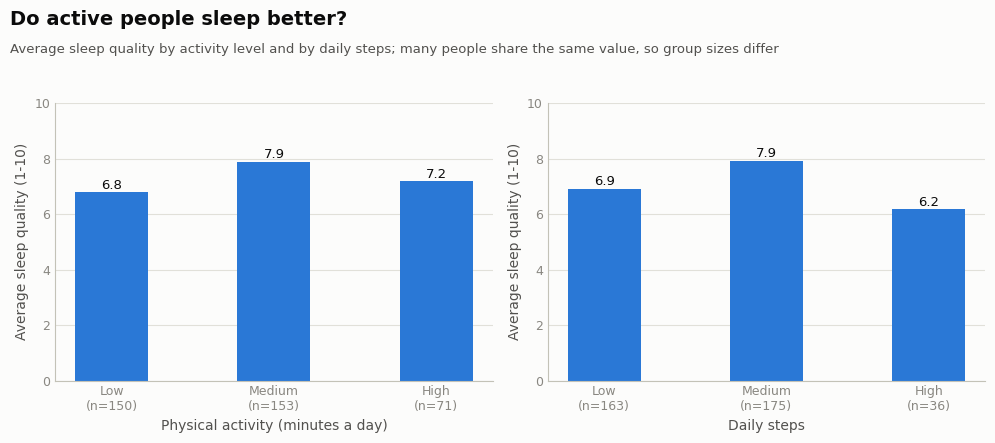

In [ ]:
df["steps_group"] = tertile_groups(df["daily_steps"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, col, xlabel in [(axes[0], "activity_group", "Physical activity (minutes a day)"),
                        (axes[1], "steps_group", "Daily steps")]:
    g = df.groupby(col, observed=False)["quality_of_sleep"].agg(["mean", "size"]).reindex(ACT_ORDER)
    xs = np.arange(len(g))
    ax.bar(xs, g["mean"].values, width=0.45, color=BLUE)
    for x, v in zip(xs, g["mean"].values):
        ax.text(x, v + 0.12, f"{v:.1f}", ha="center", fontsize=9.5, color=INK)
    ax.set_xticks(xs)
    ax.set_xticklabels([f"{lab}\n(n={int(n)})" for lab, n in zip(ACT_ORDER, g["size"])])
    ax.set_ylim(0, 10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Average sleep quality (1-10)")
    style_axes(ax)

finish(fig, "04_activity_steps_vs_quality", "Do active people sleep better?",
       "Average sleep quality by activity level and by daily steps; many people share the same value, so group sizes differ")

**Finding:** not in a simple "more is better" way. The medium-activity group has the best sleep quality (7.9), against 6.8 for low and 7.2 for high. Steps show a similar shape: medium 7.9, low 6.9, and the 36 people at exactly 10,000 steps lowest at 6.2. That last group is small, so it is a lead to check, not a conclusion. The straight-line correlations are weak: 0.19 for activity minutes and 0.02 for steps. Other factors such as occupation and stress may explain the pattern, which is why the next step tests these differences properly.

*Note on groups:* many people share exactly the same value (for example 10,000 steps), and people with equal values must stay in the same group. That is why the three groups are not equal in size.

### 4.5 Which occupations sleep the least?

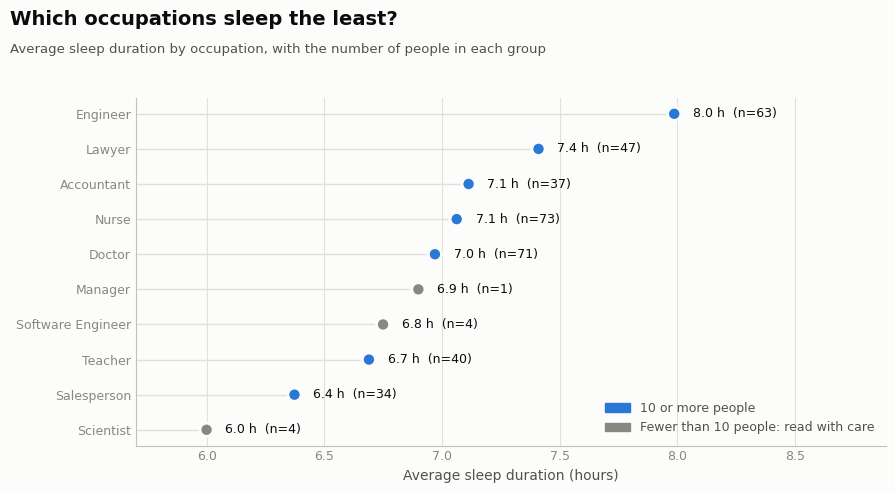

In [ ]:
occ = df.groupby("occupation").agg(duration=("sleep_duration", "mean"), quality=("quality_of_sleep", "mean"),
                                   stress=("stress_level", "mean"), n=("person_id", "count")).sort_values("duration")

fig, ax = plt.subplots(figsize=(9, 5))
ypos = np.arange(len(occ))
colours = [BLUE if n >= 10 else MUTED for n in occ["n"]]
ax.hlines(ypos, occ["duration"].min() - 0.3, occ["duration"], color=GRID, linewidth=1)
ax.scatter(occ["duration"], ypos, s=90, c=colours, edgecolors=SURFACE, linewidths=2, zorder=3)
for y, (d, n) in zip(ypos, zip(occ["duration"], occ["n"])):
    ax.text(d + 0.08, y, f"{d:.1f} h  (n={n})", va="center", fontsize=9, color=INK)
ax.set_yticks(ypos)
ax.set_yticklabels(occ.index)
ax.set_xlim(occ["duration"].min() - 0.3, occ["duration"].max() + 0.9)
ax.set_xlabel("Average sleep duration (hours)")
style_axes(ax, grid="x")
ax.legend(handles=[Patch(color=BLUE, label="10 or more people"),
                   Patch(color=MUTED, label="Fewer than 10 people: read with care")],
          frameon=False, loc="lower right", fontsize=9, labelcolor=INK2)

finish(fig, "05_occupation_sleep", "Which occupations sleep the least?",
       "Average sleep duration by occupation, with the number of people in each group")

**Finding:** among groups with at least 10 people, engineers sleep the most (8.0 hours) and salespeople the least (6.4), with teachers (6.7) close behind. Managers (1 person), scientists (4) and software engineers (4) are too small to say anything about. Sleep disorder rates by occupation (table in section 5) vary even more, from about 10% for doctors, engineers and lawyers to 78-94% for teachers, nurses and salespeople. Occupation looks like one of the most useful features for the prediction model.

### 4.6 Do sleep disorders depend on BMI?

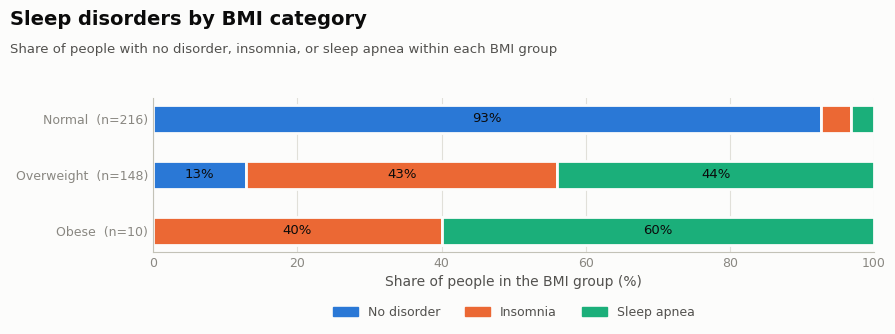

In [ ]:
ct = (pd.crosstab(df["bmi_category"], df["sleep_disorder"], normalize="index") * 100).reindex(BMI_ORDER)
ct = ct.reindex(columns=DISORDER_ORDER).fillna(0)
n_by = df["bmi_category"].value_counts()

fig, ax = plt.subplots(figsize=(9, 3.8))
ypos = np.arange(len(ct))
left = np.zeros(len(ct))
for col, colour in zip(DISORDER_ORDER, [BLUE, ORANGE, AQUA]):
    w = ct[col].values
    ax.barh(ypos, w, left=left, height=0.5, color=colour, edgecolor=SURFACE, linewidth=2)
    for y, l, v in zip(ypos, left, w):
        if v >= 10:  # only label segments wide enough to hold the text
            ax.text(l + v / 2, y, f"{v:.0f}%", ha="center", va="center", fontsize=9.5, color=text_on(colour))
    left += w
ax.set_yticks(ypos)
ax.set_yticklabels([f"{b}  (n={n_by[b]})" for b in ct.index])
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Share of people in the BMI group (%)")
style_axes(ax, grid="x")
ax.legend(handles=[Patch(color=c, label=DISORDER_LABEL[d]) for d, c in zip(DISORDER_ORDER, [BLUE, ORANGE, AQUA])],
          frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.28), fontsize=9, labelcolor=INK2)

finish(fig, "06_disorder_by_bmi", "Sleep disorders by BMI category",
       "Share of people with no disorder, insomnia, or sleep apnea within each BMI group")

**Finding:** a very sharp split. 93% of people in the Normal BMI group (216 people) have no disorder, against only 13% of the Overweight group (148 people), where insomnia (43%) and sleep apnea (44%) are about equally common. All 10 people in the Obese group have a disorder (40% insomnia, 60% sleep apnea), but 10 is too few to generalise. There is no Underweight group in this data.

### 4.7 What moves together? (correlation heatmap)

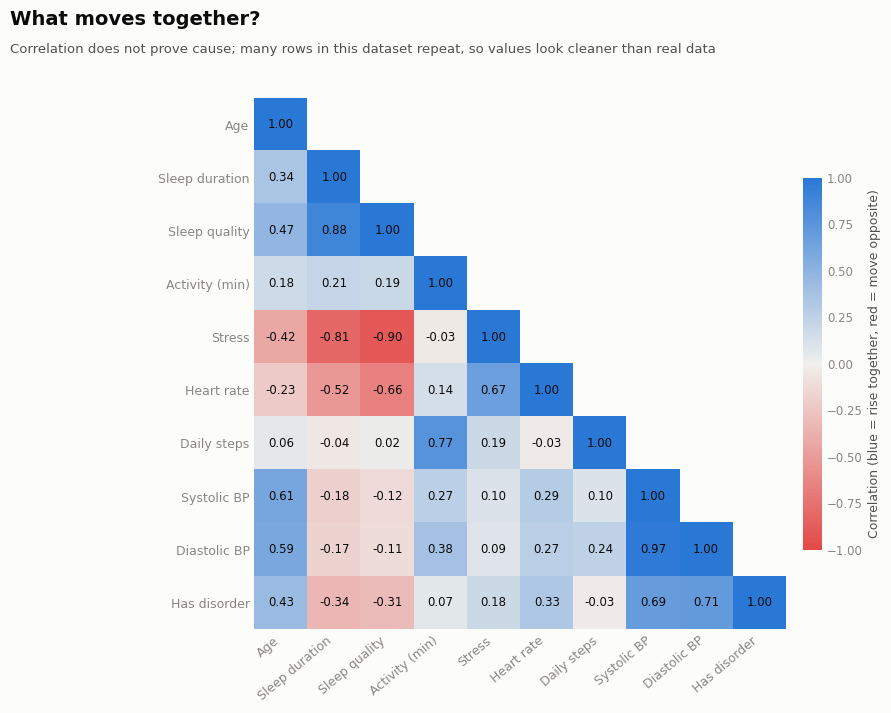

In [ ]:
num_cols = {"age": "Age", "sleep_duration": "Sleep duration", "quality_of_sleep": "Sleep quality",
            "physical_activity_level": "Activity (min)", "stress_level": "Stress", "heart_rate": "Heart rate",
            "daily_steps": "Daily steps", "systolic": "Systolic BP", "diastolic": "Diastolic BP",
            "has_disorder": "Has disorder"}
corr = df[list(num_cols)].corr()

mask = np.tril(np.ones(corr.shape, dtype=bool))      # show the lower triangle only
cmap = LinearSegmentedColormap.from_list("div", [RED, MID, BLUE])
cmap.set_bad(SURFACE)

fig, ax = plt.subplots(figsize=(9.5, 7.2))
im = ax.imshow(corr.where(mask).values, cmap=cmap, vmin=-1, vmax=1)
for i in range(len(corr)):
    for j in range(len(corr)):
        if mask[i, j]:
            v = corr.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                    color=text_on(matplotlib.colors.to_hex(cmap((v + 1) / 2))))
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(num_cols.values(), rotation=40, ha="right")
ax.set_yticklabels(num_cols.values())
for side in ax.spines.values():
    side.set_visible(False)
ax.tick_params(length=0, labelsize=9)
cb = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cb.outline.set_visible(False)
cb.ax.tick_params(length=0, labelsize=8.5, colors=MUTED)
cb.set_label("Correlation (blue = rise together, red = move opposite)", color=INK2, fontsize=9)

finish(fig, "07_correlation_heatmap", "What moves together?",
       "Correlation does not prove cause; many rows in this dataset repeat, so values look cleaner than real data")

**Finding:** sleep quality is most strongly linked to stress (-0.90), sleep duration (0.88) and resting heart rate (-0.66), then age (0.47) and having a disorder (-0.31). Activity (0.19) and steps (0.02) are weak. Two practical notes for modelling: systolic and diastolic blood pressure are almost the same signal (0.97), and activity and steps also move together (0.77), so keep only one of each pair in a model. Remember that correlation does not show cause.

### 4.8 Do men and women differ?

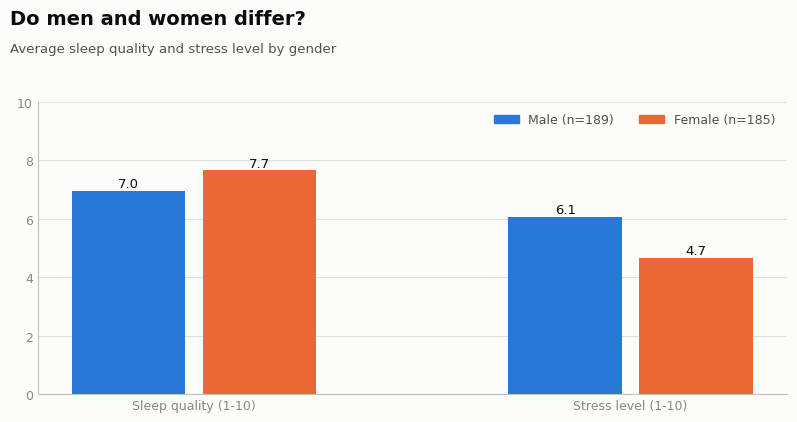

In [ ]:
metrics = {"quality_of_sleep": "Sleep quality (1-10)", "stress_level": "Stress level (1-10)"}
g = df.groupby("gender")[list(metrics)].mean()
genders = [x for x in ["Male", "Female"] if x in g.index]

fig, ax = plt.subplots(figsize=(8, 4.3))
xs = np.arange(len(metrics))
width = 0.26
for k, (gender, colour) in enumerate(zip(genders, [BLUE, ORANGE])):
    off = (k - (len(genders) - 1) / 2) * (width + 0.04)
    vals = g.loc[gender].values
    ax.bar(xs + off, vals, width=width, color=colour)
    for x, v in zip(xs + off, vals):
        ax.text(x, v + 0.12, f"{v:.1f}", ha="center", fontsize=9.5, color=INK)
ax.set_xticks(xs)
ax.set_xticklabels(metrics.values())
ax.set_ylim(0, 10)
style_axes(ax)
ax.legend(handles=[Patch(color=c, label=f"{gn} (n={int((df['gender'] == gn).sum())})")
                   for gn, c in zip(genders, [BLUE, ORANGE])],
          frameon=False, ncol=2, loc="upper right", fontsize=9, labelcolor=INK2)

finish(fig, "08_gender_comparison", "Do men and women differ?", "Average sleep quality and stress level by gender")

**Finding:** women report better sleep quality (7.7 vs 7.0) and lower stress (4.7 vs 6.1), yet 56% of women have a sleep disorder against 28% of men. These gaps may reflect occupation (different jobs have different gender mixes in this sample) rather than gender itself, so test this before drawing a conclusion.

### 4.9 How does sleep change with age?

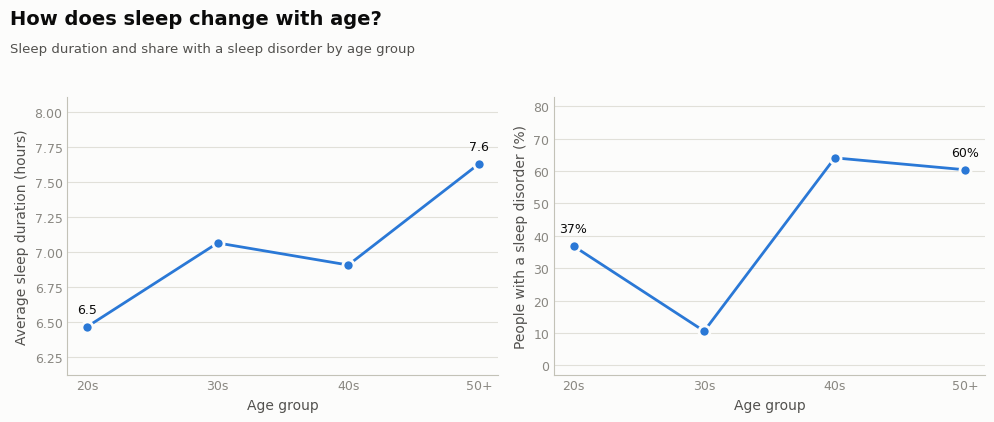

,duration,disorder,n
age_group,,,
20s,6.47,0.37,19
30s,7.07,0.11,142
40s,6.91,0.64,117
50+,7.63,0.60,96


In [ ]:
by_age = (df.groupby("age_group", observed=False)
            .agg(duration=("sleep_duration", "mean"), disorder=("has_disorder", "mean"), n=("age", "size"))
            .reindex(AGE_ORDER))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
line_panel(axes[0], AGE_ORDER, by_age["duration"].values, BLUE, "Average sleep duration (hours)")
line_panel(axes[1], AGE_ORDER, (by_age["disorder"] * 100).values, BLUE,
           "People with a sleep disorder (%)", fmt="{:.0f}%")
for ax in axes:
    ax.set_xlabel("Age group")

finish(fig, "09_age_patterns", "How does sleep change with age?",
       "Sleep duration and share with a sleep disorder by age group")
by_age.round(2)

**Finding:** average sleep rises from 6.5 hours in the 20s to 7.6 hours at 50 and over. The share with a sleep disorder is not a smooth trend: 37% in the 20s, 11% in the 30s, then 64% in the 40s and 60% at 50+. Ages in this data run from 27 to 59, and the 20s group has only 19 people, so its figures are unreliable.

## 5. Summary tables
Handy numbers to paste into a README or slide.

In [ ]:
print("=== Correlation with sleep quality (strongest first) ===")
print(corr["quality_of_sleep"].drop("quality_of_sleep").sort_values(key=abs, ascending=False).round(2).to_string())

print("\n=== Occupation summary ===")
occ["disorder_rate"] = df.groupby("occupation")["has_disorder"].mean()
print(occ.sort_values("duration").round(2).to_string())

print("\n=== Sleep disorder by BMI (row %) ===")
print(ct.round(0).to_string())

print("\n=== Gender summary ===")
print(df.groupby("gender")[["sleep_duration", "quality_of_sleep", "stress_level", "has_disorder"]].mean().round(2).to_string())

=== Correlation with sleep quality (strongest first) ===
stress_level              -0.90
sleep_duration             0.88
heart_rate                -0.66
age                        0.47
has_disorder              -0.31
physical_activity_level    0.19
systolic                  -0.12
diastolic                 -0.11
daily_steps                0.02

=== Occupation summary ===
                   duration  quality  stress   n  disorder_rate
occupation                                                     
Scientist              6.00     5.00    7.00   4           0.50
Salesperson            6.37     5.88    7.06  34           0.94
Teacher                6.69     6.98    4.53  40           0.78
Software Engineer      6.75     6.50    6.00   4           0.25
Manager                6.90     7.00    5.00   1           0.00
Doctor                 6.97     6.65    6.73  71           0.10
Nurse                  7.06     7.37    5.55  73           0.88
Accountant             7.11     7.89    4.59  37   

## 6. Statistical tests: which findings are real?
The charts above show *differences*. This section asks whether each difference is large and reliable, or could be chance.

**How to read the results**
- A **p-value** answers: "if there were no real effect, how surprising would this result be?" A small p-value means "unlikely to be chance". It does **not** say the effect is big.
- An **effect size** says how big the effect is: correlation (rho) from -1 to 1, Cramer's V from 0 to 1 for category-versus-category links, eta-squared for how much of the variation a group explains, and so on.
- **Tests used:** Spearman correlation (suits 1-10 ratings and does not need a straight-line relationship), Mann-Whitney (two groups), Kruskal-Wallis (three or more groups; the rank-based cousin of ANOVA), and chi-square (category versus category).

**The repeated-rows problem.** Section 2 showed that most rows repeat. Counting the same row many times makes p-values look far more convincing than they should. So every test below is run **twice**: on all rows, and on **unique rows only**. We also correct for running 18 tests at once (Holm correction). A finding is labelled **Holds up** only if it still passes on unique rows after that correction.

In [ ]:
import warnings

from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")

# Robustness check: keep one copy of each distinct row (ignoring Person ID)
df_unique = df.drop_duplicates(subset=[c for c in df.columns if c != "person_id"]).copy()
print(f"All rows: {len(df)} | unique rows: {len(df_unique)}")

# Occupations with at least 10 people (smaller groups are too small to test)
big_occ = df["occupation"].value_counts()
big_occ = list(big_occ[big_occ >= 10].index)
print("Occupations used in occupation tests:", big_occ)

All rows: 374 | unique rows: 132
Occupations used in occupation tests: ['Nurse', 'Doctor', 'Engineer', 'Lawyer', 'Teacher', 'Accountant', 'Salesperson']


In [ ]:
# Each helper returns a function that takes a DataFrame and gives (p-value, effect size text, warning).
def spearman(x, y):
    def run(d):
        rho, p = stats.spearmanr(d[x], d[y])
        return p, f"rho = {rho:.2f}", ""
    return run


def mann_whitney(col):
    def run(d):
        a = d.loc[d["gender"] == "Female", col]
        b = d.loc[d["gender"] == "Male", col]
        u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        return p, f"P(woman higher) = {u / (len(a) * len(b)):.2f}", ""   # 0.50 would mean no difference
    return run


def kruskal(group_col, value_col, only_big=False):
    def run(d):
        if only_big:
            d = d[d["occupation"].isin(big_occ)]
        groups = [g[value_col].values for _, g in d.groupby(group_col, observed=True)]
        h, p = stats.kruskal(*groups)
        eta2 = max(0.0, (h - len(groups) + 1) / (len(d) - len(groups)))
        return p, f"eta2 = {eta2:.2f}", ""
    return run


def chi_square(group_col, only_big=False, binary_bmi=False):
    def run(d):
        if only_big:
            d = d[d["occupation"].isin(big_occ)]
        if binary_bmi:   # Normal vs Overweight/Obese against any disorder (avoids tiny cells)
            rows = np.where(d["bmi_category"] == "Normal", "Normal", "Overweight/Obese")
            target = d["has_disorder"]
        else:
            rows, target = d[group_col], d["sleep_disorder"]
        ct = pd.crosstab(rows, target)
        c2, p, dof, expected = stats.chi2_contingency(ct)
        v = np.sqrt(c2 / (ct.values.sum() * (min(ct.shape) - 1)))
        warn = "few people in some cells" if (expected < 5).mean() > 0.2 else ""
        return p, f"Cramer's V = {v:.2f}", warn
    return run


tests = [
    ("Stress and sleep quality", "Spearman", spearman("stress_level", "quality_of_sleep")),
    ("Sleep duration and sleep quality", "Spearman", spearman("sleep_duration", "quality_of_sleep")),
    ("Resting heart rate and sleep quality", "Spearman", spearman("heart_rate", "quality_of_sleep")),
    ("Activity minutes and sleep quality", "Spearman", spearman("physical_activity_level", "quality_of_sleep")),
    ("Daily steps and sleep quality", "Spearman", spearman("daily_steps", "quality_of_sleep")),
    ("Gender and sleep quality", "Mann-Whitney", mann_whitney("quality_of_sleep")),
    ("Gender and stress", "Mann-Whitney", mann_whitney("stress_level")),
    ("Gender and sleep duration", "Mann-Whitney", mann_whitney("sleep_duration")),
    ("Occupation and sleep quality", "Kruskal-Wallis", kruskal("occupation", "quality_of_sleep", only_big=True)),
    ("Occupation and stress", "Kruskal-Wallis", kruskal("occupation", "stress_level", only_big=True)),
    ("Occupation and sleep duration", "Kruskal-Wallis", kruskal("occupation", "sleep_duration", only_big=True)),
    ("Activity group and sleep quality", "Kruskal-Wallis", kruskal("activity_group", "quality_of_sleep")),
    ("Steps group and sleep quality", "Kruskal-Wallis", kruskal("steps_group", "quality_of_sleep")),
    ("BMI (normal vs overweight/obese) and any disorder", "Chi-square", chi_square("bmi_category", binary_bmi=True)),
    ("Gender and disorder type", "Chi-square", chi_square("gender")),
    ("Occupation and disorder type", "Chi-square", chi_square("occupation", only_big=True)),
    ("Age group and disorder type", "Chi-square", chi_square("age_group")),
    ("Blood pressure group and disorder type", "Chi-square", chi_square("bp_category")),
]

rows = []
for question, test_name, run in tests:
    p_all, eff_all, _ = run(df)
    p_uni, eff_uni, warn = run(df_unique)
    rows.append({"question": question, "test": test_name, "effect_all": eff_all, "p_all": p_all,
                 "effect_unique": eff_uni, "p_unique": p_uni, "note_unique": warn})

res = pd.DataFrame(rows)
res["p_all_holm"] = multipletests(res["p_all"], method="holm")[1]
res["p_unique_holm"] = multipletests(res["p_unique"], method="holm")[1]
res["verdict"] = np.where(res["p_unique_holm"] < 0.05, "Holds up", "Not robust")


def fmt_p(p):
    return "< 0.001" if p < 0.001 else f"{p:.3f}"


show = pd.DataFrame({
    "Question": res["question"],
    "Test": res["test"],
    "Effect (all rows)": res["effect_all"],
    "p (all rows)": res["p_all_holm"].map(fmt_p),
    "Effect (unique rows)": res["effect_unique"],
    "p (unique rows)": res["p_unique_holm"].map(fmt_p),
    "Verdict": res["verdict"],
    "Note": res["note_unique"],
})
pd.set_option("display.max_colwidth", 60)
print("p-values below are Holm-adjusted for running 18 tests.")
show

p-values below are Holm-adjusted for running 18 tests.


,Question,Test,Effect (all rows),p (all rows),Effect (unique rows),p (unique rows),Verdict,Note
0,Stress and sleep quality,Spearman,rho = -0.91,< 0.001,rho = -0.90,< 0.001,Holds up,
1,Sleep duration and sleep quality,Spearman,rho = 0.89,< 0.001,rho = 0.88,< 0.001,Holds up,
2,Resting heart rate and sleep quality,Spearman,rho = -0.73,< 0.001,rho = -0.74,< 0.001,Holds up,
3,Activity minutes and sleep quality,Spearman,rho = 0.18,0.002,rho = 0.28,0.007,Holds up,
4,Daily steps and sleep quality,Spearman,rho = 0.02,0.661,rho = 0.15,0.176,Not robust,
5,Gender and sleep quality,Mann-Whitney,P(woman higher) = 0.67,< 0.001,P(woman higher) = 0.63,0.032,Holds up,
6,Gender and stress,Mann-Whitney,P(woman higher) = 0.26,< 0.001,P(woman higher) = 0.32,0.002,Holds up,
7,Gender and sleep duration,Mann-Whitney,P(woman higher) = 0.57,0.029,P(woman higher) = 0.55,0.333,Not robust,
8,Occupation and sleep quality,Kruskal-Wallis,eta2 = 0.42,< 0.001,eta2 = 0.28,< 0.001,Holds up,
9,Occupation and stress,Kruskal-Wallis,eta2 = 0.35,< 0.001,eta2 = 0.22,< 0.001,Holds up,


**What the tests say**

*Holds up, strongly*
- Stress, sleep duration and resting heart rate are strongly linked to sleep quality (rho -0.91, 0.89 and -0.73 on all rows, almost identical on unique rows).
- Occupation is strongly linked to sleep quality, stress and sleep duration (eta2 between 0.22 and 0.42), and to the type of disorder (Cramer's V 0.74 on all rows, 0.46 on unique rows).
- BMI group is strongly linked to having any disorder (V 0.80 on all rows, 0.52 on unique rows).

*Holds up, but weaker*
- Activity minutes and sleep quality (rho 0.18 on all rows, 0.28 on unique rows), and age group and blood pressure group with disorder type (V 0.27 and 0.35 on unique rows).
- Women have higher sleep quality and lower stress than men. The "P(woman higher)" figure is the chance a randomly chosen woman beats a randomly chosen man, where 0.50 means no difference: 0.67 for quality (0.63 on unique rows) and 0.26 for stress (0.32 on unique rows).

*Not robust: do not build a claim on these*
- **Daily steps and sleep quality**: rho 0.02 on all rows and 0.15 on unique rows (p = 0.18). No reliable straight-line link.
- **Gender and sleep duration**: the small gap on all rows disappears on unique rows (p = 0.33).
- **Gender and disorder type**: looked strong on all rows (V 0.38) but is not robust on unique rows (p = 0.10). Section 6.1 shows why.

*Two cautions*
- The steps *group* test passes while the steps *correlation* does not. That means the pattern is not "more steps, better sleep": the medium group sleeps best and the group at exactly 10,000 steps sleeps worst. That group has only 13 unique people, so treat it as a lead, not a finding.
- On unique rows, the occupation and blood pressure chi-square tests have some cells with very few people (see the Note column). Lean on their effect sizes rather than their p-values.

### 6.1 Does the gender gap survive once we account for other things?
Women report better sleep quality and lower stress, and far more of them have a disorder. But gender is tangled up with occupation: some jobs in this sample are almost entirely one gender. The table shows how the two overlap.

In [ ]:
dd_all = df[df["occupation"].isin(big_occ)]
dd_unique = df_unique[df_unique["occupation"].isin(big_occ)]

print("Gender mix by occupation (all rows):")
pd.crosstab(dd_all["gender"], dd_all["occupation"])

Gender mix by occupation (all rows):


occupation,Accountant,Doctor,Engineer,Lawyer,Nurse,Salesperson,Teacher
gender,,,,,,,
Female,36,2,32,2,73,0,35
Male,1,69,31,45,0,34,5


In [ ]:
def gender_models(d):
    """Gender effect (men vs women) before and after adjusting for occupation and stress."""
    quality, disorder = [], []
    for name, formula in {"Gender only": "quality_of_sleep ~ C(gender)",
                          "+ occupation": "quality_of_sleep ~ C(gender) + C(occupation)",
                          "+ occupation + stress": "quality_of_sleep ~ C(gender) + C(occupation) + stress_level"}.items():
        m = smf.ols(formula, d).fit()
        lo, hi = m.conf_int().loc["C(gender)[T.Male]"]
        quality.append((name, m.params["C(gender)[T.Male]"], lo, hi, m.pvalues["C(gender)[T.Male]"]))
    for name, formula in {"Gender only": "has_disorder ~ C(gender)",
                          "+ occupation": "has_disorder ~ C(gender) + C(occupation)"}.items():
        m = smf.logit(formula, d).fit(disp=0)
        lo, hi = np.exp(m.conf_int().loc["C(gender)[T.Male]"])
        disorder.append((name, np.exp(m.params["C(gender)[T.Male]"]), lo, hi, m.pvalues["C(gender)[T.Male]"]))
    cols = ["model", "estimate", "ci_low", "ci_high", "p"]
    return pd.DataFrame(quality, columns=cols), pd.DataFrame(disorder, columns=cols)


q_all, d_all = gender_models(dd_all)
q_uni, d_uni = gender_models(dd_unique)

print("Sleep quality: men minus women, in points on the 1-10 scale (negative = men sleep worse)")
print(pd.concat({"all rows": q_all.set_index("model").round(2), "unique rows": q_uni.set_index("model").round(2)}, axis=1).to_string())
print("\nAny sleep disorder: odds ratio, men vs women (1 = no difference, below 1 = men less likely)")
print(pd.concat({"all rows": d_all.set_index("model").round(2), "unique rows": d_uni.set_index("model").round(2)}, axis=1).to_string())

Sleep quality: men minus women, in points on the 1-10 scale (negative = men sleep worse)
                      all rows                      unique rows                     
                      estimate ci_low ci_high     p    estimate ci_low ci_high     p
model                                                                               
Gender only              -0.75  -0.98   -0.52  0.00       -0.63  -1.04   -0.21  0.00
+ occupation             -1.06  -1.40   -0.73  0.00       -1.07  -1.64   -0.50  0.00
+ occupation + stress    -0.02  -0.17    0.12  0.73        0.01  -0.28    0.30  0.93

Any sleep disorder: odds ratio, men vs women (1 = no difference, below 1 = men less likely)
             all rows                      unique rows                     
             estimate ci_low ci_high     p    estimate ci_low ci_high     p
model                                                                      
Gender only      0.30   0.19    0.46  0.00        0.53   0.26    1.07  0.08
+ oc

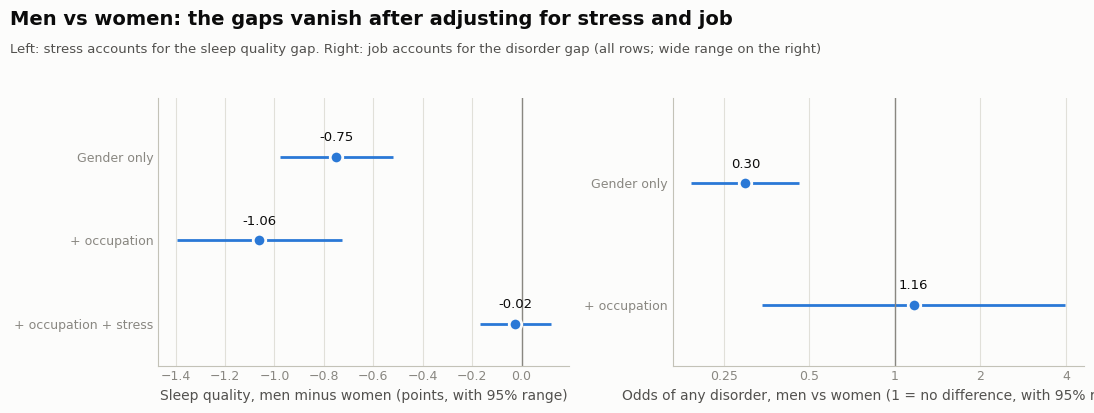

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

def effect_panel(ax, tbl, xlabel, log=False, ticks=None):
    ypos = np.arange(len(tbl))
    for y, (_, r) in zip(ypos, tbl.iterrows()):
        ax.hlines(y, r["ci_low"], r["ci_high"], color=BLUE, linewidth=2)
    ax.plot(tbl["estimate"], ypos, "o", color=BLUE, markersize=9, markeredgecolor=SURFACE, markeredgewidth=2, zorder=3)
    for y, v in zip(ypos, tbl["estimate"]):
        ax.annotate(f"{v:.2f}", (v, y), textcoords="offset points", xytext=(0, 11), ha="center", fontsize=9.5, color=INK)
    ax.axvline(1 if log else 0, color=MUTED, linewidth=1)
    if log:
        ax.set_xscale("log")
        ax.set_xticks(ticks)
        ax.set_xticklabels([str(t) for t in ticks])
        ax.minorticks_off()
    ax.set_yticks(ypos)
    ax.set_yticklabels(tbl["model"])
    ax.invert_yaxis()
    ax.set_ylim(len(tbl) - 0.5, -0.7)
    ax.set_xlabel(xlabel)
    style_axes(ax, grid="x")

effect_panel(axes[0], q_all, "Sleep quality, men minus women (points, with 95% range)")
effect_panel(axes[1], d_all, "Odds of any disorder, men vs women (1 = no difference, with 95% range)", log=True,
             ticks=[0.25, 0.5, 1, 2, 4])
finish(fig, "10_gender_gap_explained", "Men vs women: the gaps vanish after adjusting for stress and job",
       "Left: stress accounts for the sleep quality gap. Right: job accounts for the disorder gap (all rows; wide range on the right)")

**Finding: sleep quality.** On all rows, men score 0.75 points lower than women (0.63 on unique rows). Comparing people in the same job does not shrink the gap (it becomes 1.06 points, and 1.07 on unique rows), so job mix is not the explanation. But once stress level is included, the gap is essentially zero (-0.02 on all rows, 0.01 on unique rows, and both ranges include zero). In this data, men report much higher stress, and that stress accounts for the difference in sleep quality. Both measures are self-reported, and poor sleep can also raise stress, so this shows that the two overlap, not which one causes the other.

**Finding: sleep disorders.** Men look much less likely to have a disorder (odds ratio 0.30 on all rows), but that is not robust on unique rows (0.53, range includes 1). Once we compare people in the same job, the gap disappears (odds ratio 1.16 on all rows, 1.39 on unique rows). The pattern in the earlier charts is mostly a job effect: nurses (all women) and teachers (mostly women) have high disorder rates, and so do salespeople (all men), while doctors and lawyers (mostly men) have low rates.

**Limit of this analysis:** gender and job overlap heavily here (all nurses are women, all salespeople are men), so they cannot be fully separated. The very wide ranges on the right side of the chart (about 0.3 to 4) say the data cannot tell us whether a small gender effect on disorders exists.

### 6.2 What you can safely claim (and say in your README)
- **Safe to claim:** stress, sleep duration and resting heart rate are the factors most strongly linked to sleep quality, and occupation and BMI group separate sleep disorder rates sharply. These held up on unique rows after correcting for multiple tests.
- **Claim with care:** activity minutes is only weakly linked to sleep quality. The gender differences in sleep quality and in disorders are explained by stress and by occupation respectively, so describe them that way instead of as "gender effects".
- **Do not claim:** that more steps mean better sleep, or that gender affects sleep duration.
- **Always say:** the data has few unique records (132 of 374), looks synthetic, and some groups are tiny. Correlation is not cause, and a small p-value is not the same as an important effect.

*Example README line:* "Stress level was the strongest correlate of sleep quality (Spearman rho = -0.90 on 132 unique records). The apparent gender gap in sleep quality disappeared after adjusting for stress."

## What comes next
- **Step 4:** a model that predicts whether someone has a sleep disorder (compared against a simple baseline, and judged on unique rows so repeated records do not leak between training and test sets), plus clustering to find lifestyle groups.
- **Step 5:** an interactive dashboard and a GitHub README with the limitations stated up front.

## 7. Predicting sleep disorders
**Question:** can lifestyle and health measures predict whether someone has a sleep disorder, and does a complex model beat a simple rule?

**What we predict**
- First: *any* sleep disorder (yes / no).
- Then: three groups (no disorder, insomnia, sleep apnea).

**How we keep the test honest**
- Most rows in this dataset repeat. In ordinary cross-validation, a copy of the same person can land in both the training and the test data, so the model is partly tested on records it has already seen.
- We keep identical records together in the same fold (grouped cross-validation), and we also report results on **unique rows only** (132 people), which is the more honest estimate.
- Every model is compared against simple baselines: always guessing the most common answer, and using BMI category alone or occupation alone.

**How to read the scores**
- **Accuracy:** share of people classified correctly.
- **Balanced accuracy:** averages over groups so a big group cannot hide mistakes on a small one.
- **AUC:** how well the model ranks people by risk (0.5 = coin flip, 1.0 = perfect).

In [ ]:
import textwrap

from sklearn.cluster import KMeans
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, adjusted_rand_score, balanced_accuracy_score,
                             confusion_matrix, f1_score, roc_auc_score, silhouette_score)
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text

# Columns that define "the same record" (Person ID and the engineered columns are ignored)
SIGNATURE = ["gender", "age", "occupation", "sleep_duration", "quality_of_sleep",
             "physical_activity_level", "stress_level", "bmi_category", "systolic", "diastolic",
             "heart_rate", "daily_steps", "sleep_disorder"]
df["record_id"] = df.groupby(SIGNATURE, sort=False).ngroup()
unique_mask = ~df.duplicated(subset=SIGNATURE).to_numpy()
print(f"{len(df)} rows, {df['record_id'].nunique()} distinct records")

NUMERIC = ["age", "sleep_duration", "quality_of_sleep", "physical_activity_level", "stress_level",
           "heart_rate", "daily_steps", "systolic", "diastolic"]
X_all = pd.concat([df[NUMERIC],
                   pd.get_dummies(df[["gender", "occupation", "bmi_category"]]).astype(int)], axis=1)
X_bmi = pd.get_dummies(df[["bmi_category"]]).astype(int)
X_occ = pd.get_dummies(df[["occupation"]]).astype(int)

y_bin = df["has_disorder"].to_numpy()
y_3 = np.array(df["sleep_disorder"].tolist(), dtype=object)
groups = df["record_id"].to_numpy()
print(f"Always guessing 'no disorder' is right {1 - y_bin.mean():.0%} of the time (all rows).")

374 rows, 132 distinct records
Always guessing 'no disorder' is right 59% of the time (all rows).


In [ ]:
def evaluate(model, X, y, groups, binary=True, n_repeats=5):
    """Repeated 5-fold cross-validation that keeps identical records together."""
    acc, bal, extra = [], [], []
    for seed in range(n_repeats):
        cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
        if binary:
            proba = cross_val_predict(model, X, y, groups=groups, cv=cv, method="predict_proba")[:, 1]
            pred = (proba > 0.5).astype(int)
            extra.append(roc_auc_score(y, proba))
        else:
            pred = cross_val_predict(model, X, y, groups=groups, cv=cv)
            extra.append(f1_score(y, pred, average="macro"))
        acc.append(accuracy_score(y, pred))
        bal.append(balanced_accuracy_score(y, pred))
    extra_name = "auc" if binary else "macro_f1"
    return {"accuracy": np.mean(acc), "balanced_accuracy": np.mean(bal), extra_name: np.mean(extra)}


def make_models():
    return {
        "Always guess the majority class": DummyClassifier(strategy="most_frequent"),
        "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
        "Decision tree (depth 3)": DecisionTreeClassifier(max_depth=3, random_state=0),
        "Random forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=2, random_state=0),
    }


# Why grouping matters: how many test rows have an identical twin in the training data?
twin_share, leaky_acc = [], []
for seed in range(5):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    for train_idx, test_idx in skf.split(X_all, y_bin):
        twin_share.append(np.isin(groups[test_idx], groups[train_idx]).mean())
    pred = cross_val_predict(make_models()["Random forest"], X_all, y_bin, cv=skf)
    leaky_acc.append(accuracy_score(y_bin, pred))

print(f"Ordinary cross-validation: {np.mean(twin_share):.0%} of test rows have an identical twin in training.")
print(f"Random forest accuracy with that leak: {np.mean(leaky_acc):.1%}")

Ordinary cross-validation: 82% of test rows have an identical twin in training.
Random forest accuracy with that leak: 94.1%


**Why this check matters:** with ordinary cross-validation, about 8 in 10 test rows have an identical twin in the training data. With grouped cross-validation it is 0. The effect on a random forest's accuracy is small here (94% with the leak, 93% without) because the data is so regular, but it still makes results look more convincing than they are, and it matters most for the unique-rows numbers below.

In [ ]:
sets = {"All rows": np.ones(len(df), dtype=bool), "Unique rows": unique_mask}

rows = []
for set_name, m in sets.items():
    for name, model in make_models().items():
        rows.append({"data": set_name, "model": name, **evaluate(model, X_all[m], y_bin[m], groups[m])})
    rows.append({"data": set_name, "model": "BMI category only (logistic)",
                 **evaluate(make_models()["Logistic regression"], X_bmi[m], y_bin[m], groups[m])})
    rows.append({"data": set_name, "model": "Occupation only (logistic)",
                 **evaluate(make_models()["Logistic regression"], X_occ[m], y_bin[m], groups[m])})

bin_res = pd.DataFrame(rows)
bin_res.pivot(index="model", columns="data", values=["accuracy", "auc"]).round(3)

accuracy                  auc            
data                            All rows Unique rows All rows Unique rows
model                                                                    
Always guess the majority class    0.586       0.553    0.500       0.500
BMI category only (logistic)       0.906       0.773    0.880       0.732
Decision tree (depth 3)            0.932       0.792    0.909       0.824
Logistic regression                0.919       0.806    0.903       0.785
Occupation only (logistic)         0.866       0.724    0.814       0.634
Random forest                      0.919       0.839    0.905       0.799

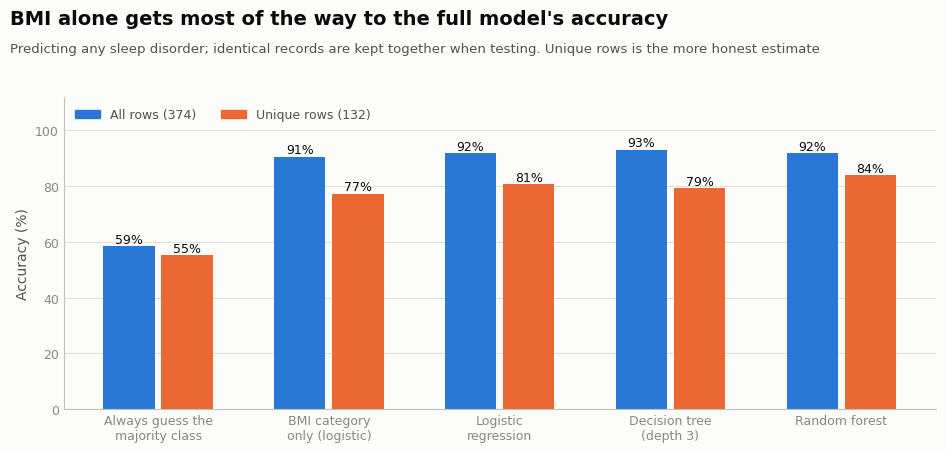

In [ ]:
plot_models = ["Always guess the majority class", "BMI category only (logistic)", "Logistic regression",
               "Decision tree (depth 3)", "Random forest"]
acc = bin_res.pivot(index="model", columns="data", values="accuracy").reindex(plot_models)

fig, ax = plt.subplots(figsize=(9.5, 4.6))
xs = np.arange(len(plot_models))
width = 0.3
for k, (label, colour) in enumerate([("All rows", BLUE), ("Unique rows", ORANGE)]):
    off = (k - 0.5) * (width + 0.04)
    vals = acc[label].values * 100
    ax.bar(xs + off, vals, width=width, color=colour)
    for x, v in zip(xs + off, vals):
        ax.text(x, v + 1.2, f"{v:.0f}%", ha="center", fontsize=9, color=INK)
ax.set_xticks(xs)
ax.set_xticklabels(["\n".join(textwrap.wrap(m, 16)) for m in plot_models])
ax.set_ylim(0, 112)
ax.set_ylabel("Accuracy (%)")
style_axes(ax)
ax.legend(handles=[Patch(color=BLUE, label="All rows (374)"), Patch(color=ORANGE, label="Unique rows (132)")],
          frameon=False, ncol=2, loc="upper left", fontsize=9, labelcolor=INK2)
finish(fig, "11_model_comparison", "BMI alone gets most of the way to the full model's accuracy",
       "Predicting any sleep disorder; identical records are kept together when testing. Unique rows is the more honest estimate")

**Finding: any sleep disorder (yes / no)**
- Always guessing "no disorder" is right 59% of the time on all rows and 55% on unique rows. That is the bar to beat.
- The random forest scores 93% on all rows and 83% on unique rows. Logistic regression (92% / 81%) and the depth-3 decision tree (92% / 80%) are within about 3 points of it, which is not a meaningful difference with 132 people.
- **A simple rule gets most of the way there.** BMI category alone scores 91% on all rows (77% on unique rows), and occupation alone scores 87% on all rows. On all rows the full model adds only 2 points over BMI alone; on unique rows it adds 6.
- A default gradient boosting model scored lower (76% on all rows, 71% on unique rows) and was left out.
- Expect lower accuracy on real data: this dataset looks synthetic, so a model may be learning the rules that generated it.


In [ ]:
rows3 = []
for set_name, m in sets.items():
    for name in ["Always guess the majority class", "Logistic regression", "Random forest"]:
        rows3.append({"data": set_name, "model": name,
                      **evaluate(make_models()[name], X_all[m], y_3[m], groups[m], binary=False)})
res3 = pd.DataFrame(rows3)
print(res3.pivot(index="model", columns="data", values=["accuracy", "balanced_accuracy", "macro_f1"]).round(3).to_string())

# Where does the random forest go wrong? (all rows, one cross-validation run)
labels = ["None", "Insomnia", "Sleep Apnea"]
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
pred3 = cross_val_predict(make_models()["Random forest"], X_all, y_3, groups=groups, cv=cv)
print("\nRows = true group, columns = predicted group (all rows)")
print(pd.DataFrame(confusion_matrix(y_3, pred3, labels=labels), index=labels, columns=labels).to_string())

# Among people who have a disorder, can the model tell insomnia from sleep apnea?
print()
for set_name, m in sets.items():
    has = (y_3 != "None") & m
    res = evaluate(make_models()["Random forest"], X_all[has], y_3[has], groups[has], binary=False)
    chance = pd.Series(y_3[has]).value_counts(normalize=True).max()
    print(f"Insomnia vs sleep apnea, {set_name}: accuracy {res['accuracy']:.1%} (guessing: {chance:.1%}, n={int(has.sum())})")

                                accuracy             balanced_accuracy             macro_f1            
data                            All rows Unique rows          All rows Unique rows All rows Unique rows
model                                                                                                  
Always guess the majority class    0.586       0.553             0.333       0.333    0.246       0.237
Logistic regression                0.872       0.726             0.833       0.674    0.835       0.676
Random forest                      0.862       0.752             0.827       0.685    0.825       0.689

Rows = true group, columns = predicted group (all rows)
             None  Insomnia  Sleep Apnea
None          202        12            5
Insomnia        8        62            7
Sleep Apnea     6        11           61

Insomnia vs sleep apnea, All rows: accuracy 82.5% (guessing: 50.3%, n=155)
Insomnia vs sleep apnea, Unique rows: accuracy 61.4% (guessing: 50.8%, n=59)


**Finding: three groups (none / insomnia / sleep apnea)**
- Guessing "none" scores 59% on all rows and 55% on unique rows. The logistic regression and random forest score 88% and 87% on all rows, and 73% and 75% on unique rows (balanced accuracy about 0.68 on unique rows). Three-way prediction is clearly harder than yes / no.
- In the confusion table, most mistakes are between healthy people and either disorder. Of the 155 people with a disorder, 14 were mistaken for the other disorder and 13 for no disorder.
- The last output line shows how well the model separates insomnia from sleep apnea. The all-rows figure is likely optimistic because of the repeated rows, so **quote the unique-rows figure** in your README.

In [ ]:
# Which features carry the signal? Each feature alone, scored on its own.
def single_feature_auc(X_cols):
    scores = []
    for seed in range(3):
        cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
        proba = cross_val_predict(DecisionTreeClassifier(max_depth=3, random_state=0), X_cols, y_bin,
                                  groups=groups, cv=cv, method="predict_proba")[:, 1]
        scores.append(roc_auc_score(y_bin, proba))
    return np.mean(scores)


single = {c: single_feature_auc(df[[c]]) for c in NUMERIC}
single["bmi_category"] = single_feature_auc(X_bmi)
single["occupation"] = single_feature_auc(X_occ)
single["gender"] = single_feature_auc(pd.get_dummies(df[["gender"]]).astype(int))
print("AUC of each feature on its own (0.5 = useless, 1.0 = perfect):")
print(pd.Series(single).sort_values(ascending=False).round(3).to_string())

# What happens to the random forest if we remove the strongest features?
drops = {"All features": [], "Without BMI": ["bmi_category"], "Without occupation": ["occupation"],
         "Without BMI and occupation": ["bmi_category", "occupation"]}
print("\nRandom forest accuracy (all rows):")
for label, drop in drops.items():
    cols = [c for c in X_all.columns if not any(c.startswith(d) for d in drop)]
    print(f"  {label:28s} {evaluate(make_models()['Random forest'], X_all[cols], y_bin, groups)['accuracy']:.1%}")

AUC of each feature on its own (0.5 = useless, 1.0 = perfect):
systolic                   0.883
bmi_category               0.880
diastolic                  0.876
occupation                 0.840
sleep_duration             0.824
physical_activity_level    0.781
age                        0.778
daily_steps                0.768
heart_rate                 0.722
quality_of_sleep           0.710
stress_level               0.706
gender                     0.566

Random forest accuracy (all rows):
  All features                 91.9%
  Without BMI                  92.2%
  Without occupation           91.9%
  Without BMI and occupation   91.2%


**Finding: which features matter?**
- On their own, BMI category (AUC 0.89), systolic and diastolic blood pressure (0.87), sleep duration (0.87) and occupation (0.85) are the strongest signals. Steps (0.83), age (0.80) and activity (0.78) come next. Stress (0.71), resting heart rate (0.70), sleep quality (0.68) and gender (0.60) are weaker for predicting a *disorder*, even though stress and quality are tightly linked to each other.
- Removing BMI, occupation, or both leaves the random forest at about 93%. The information is spread across overlapping features, so no single feature is essential, and "which feature is most important" has no clean answer in this data.
- That is also why permutation importance is not used here. With overlapping features, shuffling one feature barely hurts the model, so every feature looks unimportant (we checked: all values were close to zero).

In [ ]:
# A readable rule set (depth 3), fit on all rows. Weights are [no disorder, disorder].
X_tree = pd.concat([df[NUMERIC], X_bmi], axis=1)
tree = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_tree, y_bin)
print(export_text(tree, feature_names=list(X_tree.columns), show_weights=True))

|--- bmi_category_Normal <= 0.50
|   |--- systolic <= 128.50
|   |   |--- weights: [10.00, 0.00] class: 0
|   |--- systolic >  128.50
|   |   |--- age <= 43.50
|   |   |   |--- weights: [0.00, 30.00] class: 1
|   |   |--- age >  43.50
|   |   |   |--- weights: [9.00, 109.00] class: 1
|--- bmi_category_Normal >  0.50
|   |--- quality_of_sleep <= 5.50
|   |   |--- weights: [0.00, 4.00] class: 1
|   |--- quality_of_sleep >  5.50
|   |   |--- systolic <= 129.00
|   |   |   |--- weights: [148.00, 6.00] class: 0
|   |   |--- systolic >  129.00
|   |   |   |--- weights: [52.00, 6.00] class: 0



**Reading the rules** (illustrative; thresholds may differ slightly on your run)
- The first split is BMI. Among overweight or obese people with systolic blood pressure above about 128, almost everyone has a disorder (139 of 148).
- Among normal-BMI people with sleep quality above 5.5, almost nobody does (200 of 212 have no disorder).
- This tree is fit on all rows to show the pattern. Its accuracy is the cross-validated figure in the table above, not the tree's score on its own training data.

## 8. Lifestyle profiles (clustering)
Instead of predicting, this section asks whether the people fall into natural groups. We use K-Means on standardised lifestyle and health measures, on **unique rows only** so repeated records do not count several times. The sleep disorder column is *not* used to form the groups, so differences in disorder rates between groups are an independent check that the groups mean something.

In [ ]:
df_u = df.drop_duplicates(subset=SIGNATURE).reset_index(drop=True)   # one row per distinct record
CLUSTER_FEATURES = ["age", "sleep_duration", "quality_of_sleep", "physical_activity_level",
                    "stress_level", "heart_rate", "daily_steps", "systolic"]
Z = StandardScaler().fit_transform(df_u[CLUSTER_FEATURES])

k_rows = []
for k in range(2, 8):
    km_k = KMeans(n_clusters=k, n_init=20, random_state=0).fit(Z)
    k_rows.append({"k": k, "silhouette": silhouette_score(Z, km_k.labels_), "inertia": km_k.inertia_})
pd.DataFrame(k_rows).round(3)

,k,silhouette,inertia
0,2,0.330,698.452
1,3,0.394,543.540
2,4,0.425,401.055
3,5,0.377,344.928
4,6,0.453,275.854
5,7,0.468,236.835


**Choosing the number of groups.** Silhouette scores (higher = tighter, better separated groups) are modest, from about 0.33 to 0.47, and do not point to one clear answer. Larger k scores slightly higher but splits 132 people into groups too small to describe. We use **k = 4** because the groups are easy to explain and stay almost identical when the algorithm is restarted, not because four is the "true" number of groups.

In [ ]:
K = 4
km = KMeans(n_clusters=K, n_init=50, random_state=0).fit(Z)
df_u["cluster_raw"] = km.labels_

stability = [adjusted_rand_score(km.labels_, KMeans(n_clusters=K, n_init=50, random_state=s).fit(Z).labels_)
             for s in range(1, 6)]
print(f"Silhouette: {silhouette_score(Z, km.labels_):.2f} | "
      f"agreement across random restarts (1 = identical): {np.mean(stability):.2f}")

profile = df_u.groupby("cluster_raw").agg(
    people=("age", "size"), age=("age", "mean"), sleep_hours=("sleep_duration", "mean"),
    sleep_quality=("quality_of_sleep", "mean"), activity_min=("physical_activity_level", "mean"),
    stress=("stress_level", "mean"), heart_rate=("heart_rate", "mean"), steps=("daily_steps", "mean"),
    systolic=("systolic", "mean"), disorder_rate=("has_disorder", "mean"),
    share_women=("gender", lambda s: (s == "Female").mean()),
    share_overweight=("bmi_category", lambda s: (s != "Normal").mean()),
)

# Name the groups in order of average stress (lowest to highest).
# Check the printed table matches these names; if your groups look different, edit NAMES.
order = profile.sort_values("stress").index
NAMES = ["Calm, well-rested", "Active, low-risk", "Stressed, short sleepers", "Highest stress, very active"]
name_map = dict(zip(order, NAMES))
profile = profile.loc[order].rename(index=name_map)
df_u["cluster"] = df_u["cluster_raw"].map(name_map)

print(profile.round(2).to_string())
print("\nMost common jobs in each group:")
for name in profile.index:
    print(f"  {name}: {df_u.loc[df_u['cluster'] == name, 'occupation'].value_counts().head(3).to_dict()}")

Silhouette: 0.43 | agreement across random restarts (1 = identical): 0.97
                             people    age  sleep_hours  sleep_quality  activity_min  stress  heart_rate     steps  systolic  disorder_rate  share_women  share_overweight
cluster_raw                                                                                                                                                               
Calm, well-rested                26  52.58         7.85           8.54         52.88    3.27       67.12   5873.08    133.62           0.54         0.96              0.65
Active, low-risk                 48  36.71         7.51           7.81         70.52    4.85       68.92   7575.00    122.19           0.17         0.29              0.02
Stressed, short sleepers         47  37.32         6.46           5.98         41.66    6.91       74.91   5317.02    129.04           0.60         0.32              0.64
Highest stress, very active      11  49.64         6.06           6.00 

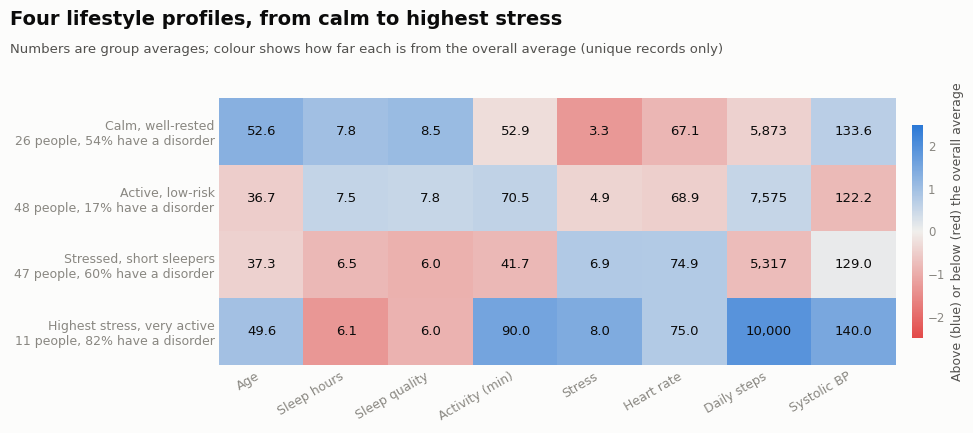

In [ ]:
heat_cols = {"age": "Age", "sleep_duration": "Sleep hours", "quality_of_sleep": "Sleep quality",
             "physical_activity_level": "Activity (min)", "stress_level": "Stress", "heart_rate": "Heart rate",
             "daily_steps": "Daily steps", "systolic": "Systolic BP"}
means = df_u.groupby("cluster")[list(heat_cols)].mean().loc[profile.index]
overall = df_u[list(heat_cols)]
zscores = (means - overall.mean()) / overall.std()

norm = matplotlib.colors.Normalize(vmin=-2.5, vmax=2.5)
cmap_c = LinearSegmentedColormap.from_list("div", [RED, MID, BLUE])

fig, ax = plt.subplots(figsize=(10.5, 4.4))
im = ax.imshow(zscores.values, cmap=cmap_c, norm=norm, aspect="auto")
for i in range(len(means)):
    for j, col in enumerate(heat_cols):
        v = means.iloc[i, j]
        label = f"{v:,.0f}" if col == "daily_steps" else f"{v:.1f}"
        shade = matplotlib.colors.to_hex(cmap_c(norm(zscores.iloc[i, j])))
        ax.text(j, i, label, ha="center", va="center", fontsize=9.5, color=text_on(shade))
ax.set_xticks(range(len(heat_cols)))
ax.set_xticklabels(list(heat_cols.values()), rotation=30, ha="right")
ax.set_yticks(range(len(means)))
ax.set_yticklabels([f"{n}\n{int(profile.loc[n, 'people'])} people, {profile.loc[n, 'disorder_rate']:.0%} have a disorder"
                    for n in means.index])
for side in ax.spines.values():
    side.set_visible(False)
ax.tick_params(length=0, labelsize=9)
cb = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cb.outline.set_visible(False)
cb.ax.tick_params(length=0, labelsize=8.5, colors=MUTED)
cb.set_label("Above (blue) or below (red) the overall average", color=INK2, fontsize=9)
finish(fig, "12_lifestyle_profiles", "Four lifestyle profiles, from calm to highest stress",
       "Numbers are group averages; colour shows how far each is from the overall average (unique records only)")

**The four profiles** (unique records, n = 132)
- **Calm, well-rested (about 26 people):** oldest group (average age about 53), sleeps 7.9 hours, sleep quality 8.5, stress 3.3, almost all women. Yet 54% have a sleep disorder. Reporting good sleep and having a diagnosed disorder are not the same thing in this data.
- **Active, low-risk (about 48 people):** average age 37, sleeps 7.5 hours, quality 7.8, 70 minutes of activity a day, lowest blood pressure (systolic about 122), 2% overweight, mostly men. Only 17% have a disorder.
- **Stressed, short sleepers (about 47 people):** sleeps 6.5 hours, quality 6.0, stress 6.9, only about 42 minutes of activity, highest resting heart rate among the larger groups, 64% overweight, 60% have a disorder.
- **Highest stress, very active (11 people):** all nurses, average age about 50, stress 8, 90 minutes of activity and 10,000 steps a day, but only 6.1 hours of sleep, systolic blood pressure about 140. All are overweight or obese, and 82% have a disorder. This is a small group of very similar records, so treat it as a pattern worth checking, not a finding.

**Why this is believable:** disorder rates differ a lot across the groups (17% to 82%) even though the disorder column was never used to build them, and the groups stay almost identical when the algorithm is restarted (agreement about 0.97). **Why it is not proof:** silhouette is only about 0.43, so groups overlap, and the profiles describe this dataset, which looks synthetic.

## Conclusions and limitations
- **Stress is the factor most tied to sleep quality** (Spearman rho about -0.90, holds on unique records). Steps show no reliable link, and activity only a weak one.
- **BMI and occupation separate sleep disorder rates sharply.** Gender gaps in sleep quality and in disorders are explained by stress and by occupation, not by gender itself.
- **A model can flag disorders at about 83% accuracy on distinct records (guessing: 55%), but BMI alone reaches 77%.** The model adds a few points, not a transformation.
- **Four lifestyle profiles** range from 17% to 82% with a disorder.
- **Limits:** only 132 of 374 records are distinct, the data looks synthetic, some groups are tiny (managers 1, scientists 4, software engineers 4, obese BMI group 10), stress and sleep quality are self-reported, and everything here is association, not cause. This is a portfolio analysis, not a medical tool.

## 9. SQL: cleaning, data model and business questions
This section repeats the cleaning in SQL and answers the business questions with queries. It uses DuckDB, a SQL engine that runs inside Colab and uses PostgreSQL-style syntax.

**Flow:** raw CSV, then `01_clean_and_model.sql` (a clean fact table plus lookup tables), then a reconciliation check against the pandas results, then `02_business_questions.sql` (13 queries), then CSV exports for Power BI.

In [ ]:
!pip install -q duckdb

import re
import shutil
from pathlib import Path

import duckdb
from IPython.display import display

os.makedirs("sql", exist_ok=True)
os.makedirs("powerbi", exist_ok=True)

# Load the raw CSV (df_raw from Section 2) with snake_case column names
raw = df_raw.copy()
raw.columns = (raw.columns.str.replace(r"\(.*?\)", "", regex=True).str.strip().str.lower()
               .str.replace(r"[^a-z0-9]+", "_", regex=True).str.strip("_"))

con = duckdb.connect()
con.register("raw_df", raw)
con.execute("CREATE OR REPLACE TABLE raw_sleep AS SELECT * FROM raw_df")
print(con.sql("SELECT COUNT(*) AS rows_loaded FROM raw_sleep").df())

   rows_loaded
0          374


In [ ]:
%%writefile sql/01_clean_and_model.sql
-- 01_clean_and_model.sql
-- Input : raw_sleep (the CSV loaded as-is, snake_case column names)
-- Output: fact_sleep (one clean row per person) and small lookup tables (dim_*) for Power BI
-- Dialect: DuckDB, which is close to PostgreSQL

-- 1. Clean the raw data and add analysis columns
CREATE OR REPLACE TABLE fact_sleep AS
WITH tidy AS (
    SELECT
        person_id,
        TRIM(gender)                                         AS gender,
        age,
        CASE WHEN TRIM(occupation) = 'Sales Representative' THEN 'Salesperson'
             ELSE TRIM(occupation) END                       AS occupation,
        sleep_duration,
        quality_of_sleep,
        physical_activity_level,
        stress_level,
        CASE WHEN TRIM(bmi_category) = 'Normal Weight' THEN 'Normal'
             ELSE TRIM(bmi_category) END                     AS bmi_category,
        CAST(SPLIT_PART(blood_pressure, '/', 1) AS INTEGER)  AS systolic,
        CAST(SPLIT_PART(blood_pressure, '/', 2) AS INTEGER)  AS diastolic,
        heart_rate,
        daily_steps,
        COALESCE(NULLIF(TRIM(sleep_disorder), ''), 'None')   AS sleep_disorder
    FROM raw_sleep
),
cutoffs AS (
    -- one-third and two-thirds cut-points, so people with the same value always share a group
    SELECT
        quantile_cont(physical_activity_level, 1.0 / 3) AS act_lo,
        quantile_cont(physical_activity_level, 2.0 / 3) AS act_hi,
        quantile_cont(daily_steps, 1.0 / 3)             AS steps_lo,
        quantile_cont(daily_steps, 2.0 / 3)             AS steps_hi
    FROM tidy
),
flagged AS (
    -- copy_number = 1 marks the first time each distinct record appears
    SELECT
        tidy.*,
        ROW_NUMBER() OVER (
            PARTITION BY gender, age, occupation, sleep_duration, quality_of_sleep,
                         physical_activity_level, stress_level, bmi_category, systolic,
                         diastolic, heart_rate, daily_steps, sleep_disorder
            ORDER BY person_id
        ) AS copy_number
    FROM tidy
)
SELECT
    f.person_id, f.gender, f.age, f.occupation, f.sleep_duration, f.quality_of_sleep,
    f.physical_activity_level, f.stress_level, f.bmi_category, f.systolic, f.diastolic,
    f.heart_rate, f.daily_steps, f.sleep_disorder,
    CASE WHEN f.sleep_disorder <> 'None' THEN 1 ELSE 0 END AS has_disorder,
    CASE WHEN f.age < 30 THEN '20s'
         WHEN f.age < 40 THEN '30s'
         WHEN f.age < 50 THEN '40s'
         ELSE '50+' END AS age_group,
    CASE WHEN f.sleep_duration < 6 THEN 'Short (<6h)'
         WHEN f.sleep_duration < 8 THEN 'Healthy (6 to <8h)'
         ELSE 'Long (8h+)' END AS sleep_category,
    CASE WHEN f.physical_activity_level <= c.act_lo THEN 'Low'
         WHEN f.physical_activity_level <= c.act_hi THEN 'Medium'
         ELSE 'High' END AS activity_group,
    CASE WHEN f.daily_steps <= c.steps_lo THEN 'Low'
         WHEN f.daily_steps <= c.steps_hi THEN 'Medium'
         ELSE 'High' END AS steps_group,
    CASE WHEN f.stress_level <= 4 THEN 'Low (1-4)'
         WHEN f.stress_level <= 6 THEN 'Medium (5-6)'
         ELSE 'High (7-10)' END AS stress_band,
    CASE WHEN f.systolic >= 140 OR f.diastolic >= 90 THEN 'High'
         WHEN f.systolic >= 130 OR f.diastolic >= 80 THEN 'Elevated'
         ELSE 'Normal' END AS bp_category,
    -- rule of thumb read off a decision tree fit on this same data, so not validated on new people
    CASE WHEN f.bmi_category <> 'Normal' AND f.systolic >= 129 THEN 'Higher-risk profile'
         WHEN f.bmi_category = 'Normal' AND f.quality_of_sleep >= 6 THEN 'Lower-risk profile'
         ELSE 'Mixed profile' END AS risk_segment,
    f.copy_number,
    CASE WHEN f.copy_number = 1 THEN 'Distinct record' ELSE 'Repeated copy' END AS record_type
FROM flagged f
CROSS JOIN cutoffs c;

-- 2. Lookup tables (they give Power BI a sort order and a few handy attributes)
CREATE OR REPLACE TABLE dim_age_group AS
SELECT * FROM (VALUES ('20s', 1), ('30s', 2), ('40s', 3), ('50+', 4)) AS t(age_group, sort_order);

CREATE OR REPLACE TABLE dim_bmi AS
SELECT * FROM (VALUES ('Normal', 1), ('Overweight', 2), ('Obese', 3)) AS t(bmi_category, sort_order);

CREATE OR REPLACE TABLE dim_sleep_category AS
SELECT * FROM (VALUES ('Short (<6h)', 1), ('Healthy (6 to <8h)', 2), ('Long (8h+)', 3)) AS t(sleep_category, sort_order);

CREATE OR REPLACE TABLE dim_activity AS
SELECT * FROM (VALUES ('Low', 1), ('Medium', 2), ('High', 3)) AS t(activity_group, sort_order);

CREATE OR REPLACE TABLE dim_stress_band AS
SELECT * FROM (VALUES ('Low (1-4)', 1), ('Medium (5-6)', 2), ('High (7-10)', 3)) AS t(stress_band, sort_order);

CREATE OR REPLACE TABLE dim_disorder AS
SELECT * FROM (VALUES ('None', 'No disorder', 1), ('Insomnia', 'Insomnia', 2), ('Sleep Apnea', 'Sleep apnea', 3))
    AS t(sleep_disorder, disorder_label, sort_order);

CREATE OR REPLACE TABLE dim_bp AS
SELECT * FROM (VALUES ('Normal', 1), ('Elevated', 2), ('High', 3)) AS t(bp_category, sort_order);

CREATE OR REPLACE TABLE dim_risk_segment AS
SELECT * FROM (VALUES ('Higher-risk profile', 1), ('Mixed profile', 2), ('Lower-risk profile', 3))
    AS t(risk_segment, sort_order);

CREATE OR REPLACE TABLE dim_occupation AS
SELECT occupation,
       COUNT(*) AS people_in_data,
       CASE WHEN COUNT(*) >= 10 THEN '10 or more people' ELSE 'Under 10 people' END AS group_size
FROM fact_sleep
GROUP BY occupation;

Writing sql/01_clean_and_model.sql


In [ ]:
def run_script(path):
    """Run every statement in a .sql file (statements are separated by semicolons)."""
    for stmt in Path(path).read_text().split(";"):
        body = "\n".join(l for l in stmt.splitlines() if not l.strip().startswith("--")).strip()
        if body:
            con.execute(stmt)


run_script("sql/01_clean_and_model.sql")

# Reconciliation: the SQL result must match the pandas result from Section 3
sql_counts = con.sql("""
    SELECT COUNT(*) AS rows_total,
           SUM(has_disorder) AS with_disorder,
           SUM(CASE WHEN copy_number = 1 THEN 1 ELSE 0 END) AS distinct_records,
           ROUND(AVG(sleep_duration), 4) AS avg_hours,
           SUM(CASE WHEN activity_group = 'Low' THEN 1 ELSE 0 END) AS activity_low,
           SUM(CASE WHEN bp_category = 'High' THEN 1 ELSE 0 END) AS bp_high
    FROM fact_sleep""").df().iloc[0]

py_counts = {"rows_total": len(df), "with_disorder": int(df["has_disorder"].sum()),
             "distinct_records": len(df_unique), "avg_hours": round(df["sleep_duration"].mean(), 4),
             "activity_low": int((df["activity_group"] == "Low").sum()),
             "bp_high": int((df["bp_category"] == "High").sum())}

for name, expected in py_counts.items():
    got = float(sql_counts[name])
    print(f"{name:18s} SQL {got:>10.4f} | pandas {float(expected):>10.4f} | {'MATCH' if abs(got - expected) < 1e-6 else 'MISMATCH'}")

rows_total         SQL   374.0000 | pandas   374.0000 | MATCH
with_disorder      SQL   155.0000 | pandas   155.0000 | MATCH
distinct_records   SQL   132.0000 | pandas   132.0000 | MATCH
avg_hours          SQL     7.1321 | pandas     7.1321 | MATCH
activity_low       SQL   150.0000 | pandas   150.0000 | MATCH
bp_high            SQL   100.0000 | pandas   100.0000 | MATCH


**Reconciliation:** every line above should say MATCH. This is a standard analyst habit: when two independent pipelines (SQL and pandas) produce the same numbers, you can trust both.

**One small fix:** the sleep categories in Section 3 label people who sleep exactly 8.0 hours as "Long (>8h)". The SQL uses the accurate labels `Short (<6h)`, `Healthy (6 to <8h)` and `Long (8h+)` with the same cut-offs, so the counts are identical. In Section 3 (and `step1_clean.py`), change the labels to `["Short (<6h)", "Healthy (6 to <8h)", "Long (8h+)"]` to match.

In [ ]:
%%writefile sql/02_business_questions.sql
-- 02_business_questions.sql
-- Thirteen business questions answered with SQL on fact_sleep. Each starts with a line "-- Qnn: question".

-- Q01: How many rows are there, and how many are exact repeats?
SELECT COUNT(*) AS rows_total,
       SUM(CASE WHEN copy_number = 1 THEN 1 ELSE 0 END) AS distinct_records,
       SUM(CASE WHEN copy_number > 1 THEN 1 ELSE 0 END) AS repeated_rows,
       SUM(CASE WHEN age IS NULL OR sleep_duration IS NULL OR quality_of_sleep IS NULL
                  OR stress_level IS NULL OR heart_rate IS NULL OR daily_steps IS NULL
                  OR systolic IS NULL THEN 1 ELSE 0 END) AS rows_with_missing_values
FROM fact_sleep;

-- Q02: What does the average person look like?
SELECT ROUND(AVG(age), 1) AS avg_age,
       ROUND(AVG(sleep_duration), 2) AS avg_sleep_hours,
       ROUND(AVG(quality_of_sleep), 2) AS avg_sleep_quality,
       ROUND(AVG(stress_level), 2) AS avg_stress,
       ROUND(100.0 * AVG(has_disorder), 1) AS pct_with_disorder
FROM fact_sleep;

-- Q03: How common is each sleep disorder? (window function for the share of the total)
SELECT sleep_disorder,
       COUNT(*) AS people,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_of_all
FROM fact_sleep
GROUP BY sleep_disorder
ORDER BY people DESC;

-- Q04: How does sleep change as stress rises? (LAG shows the step from the previous stress level)
SELECT stress_level,
       COUNT(*) AS people,
       ROUND(AVG(quality_of_sleep), 2) AS avg_quality,
       ROUND(AVG(sleep_duration), 2) AS avg_hours,
       ROUND(AVG(quality_of_sleep) - LAG(AVG(quality_of_sleep)) OVER (ORDER BY stress_level), 2) AS quality_change_vs_previous_level
FROM fact_sleep
GROUP BY stress_level
ORDER BY stress_level;

-- Q05: How do outcomes change across stress bands?
SELECT stress_band,
       COUNT(*) AS people,
       ROUND(AVG(sleep_duration), 2) AS avg_hours,
       ROUND(AVG(quality_of_sleep), 2) AS avg_quality,
       ROUND(100.0 * AVG(CASE WHEN sleep_duration < 7 THEN 1 ELSE 0 END), 0) AS pct_under_7h,
       ROUND(100.0 * AVG(has_disorder), 0) AS pct_with_disorder
FROM fact_sleep
GROUP BY stress_band
ORDER BY MIN(stress_level);

-- Q06: Which factors move together with sleep quality? (Pearson correlation, all rows vs distinct records)
SELECT 'Stress' AS factor,
       ROUND(CORR(stress_level, quality_of_sleep), 2) AS all_rows,
       ROUND(CORR(stress_level, quality_of_sleep) FILTER (WHERE copy_number = 1), 2) AS distinct_records
FROM fact_sleep
UNION ALL
SELECT 'Sleep duration',
       ROUND(CORR(sleep_duration, quality_of_sleep), 2),
       ROUND(CORR(sleep_duration, quality_of_sleep) FILTER (WHERE copy_number = 1), 2)
FROM fact_sleep
UNION ALL
SELECT 'Resting heart rate',
       ROUND(CORR(heart_rate, quality_of_sleep), 2),
       ROUND(CORR(heart_rate, quality_of_sleep) FILTER (WHERE copy_number = 1), 2)
FROM fact_sleep
UNION ALL
SELECT 'Activity minutes',
       ROUND(CORR(physical_activity_level, quality_of_sleep), 2),
       ROUND(CORR(physical_activity_level, quality_of_sleep) FILTER (WHERE copy_number = 1), 2)
FROM fact_sleep
UNION ALL
SELECT 'Daily steps',
       ROUND(CORR(daily_steps, quality_of_sleep), 2),
       ROUND(CORR(daily_steps, quality_of_sleep) FILTER (WHERE copy_number = 1), 2)
FROM fact_sleep;

-- Q07: Which occupations sleep the least? (only groups with 10 or more people, ranked)
SELECT occupation,
       COUNT(*) AS people,
       ROUND(AVG(sleep_duration), 2) AS avg_hours,
       ROUND(AVG(quality_of_sleep), 2) AS avg_quality,
       ROUND(AVG(stress_level), 2) AS avg_stress,
       ROUND(100.0 * AVG(has_disorder), 0) AS pct_with_disorder,
       RANK() OVER (ORDER BY AVG(sleep_duration)) AS shortest_sleep_rank
FROM fact_sleep
GROUP BY occupation
HAVING COUNT(*) >= 10
ORDER BY shortest_sleep_rank;

-- Q08: How do disorders split within each BMI group? (percentage within the group)
SELECT bmi_category,
       sleep_disorder,
       COUNT(*) AS people,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY bmi_category), 1) AS pct_of_bmi_group
FROM fact_sleep
GROUP BY bmi_category, sleep_disorder
ORDER BY bmi_category, sleep_disorder;

-- Q09: Is the gender gap really an occupation effect? (compare men and women within the same job)
SELECT occupation,
       gender,
       COUNT(*) AS people,
       ROUND(AVG(quality_of_sleep), 2) AS avg_quality,
       ROUND(AVG(stress_level), 2) AS avg_stress,
       ROUND(100.0 * AVG(has_disorder), 0) AS pct_with_disorder
FROM fact_sleep
GROUP BY occupation, gender
HAVING COUNT(*) >= 5
ORDER BY occupation, gender;

-- Q10: Which occupation and BMI combinations have the highest disorder rates? (CTE, groups of 10 or more)
WITH combo AS (
    SELECT occupation,
           bmi_category,
           COUNT(*) AS people,
           AVG(has_disorder) AS disorder_rate
    FROM fact_sleep
    GROUP BY occupation, bmi_category
)
SELECT occupation,
       bmi_category,
       people,
       ROUND(100.0 * disorder_rate, 0) AS pct_with_disorder
FROM combo
WHERE people >= 10
ORDER BY disorder_rate DESC, people DESC;

-- Q11: How do sleep and disorder rates change with age?
SELECT age_group,
       COUNT(*) AS people,
       ROUND(AVG(sleep_duration), 2) AS avg_hours,
       ROUND(AVG(sleep_duration) - (SELECT AVG(sleep_duration) FROM fact_sleep), 2) AS hours_vs_overall,
       ROUND(100.0 * AVG(has_disorder), 0) AS pct_with_disorder
FROM fact_sleep
GROUP BY age_group
ORDER BY age_group;

-- Q12: Does a simple rule of thumb separate disorder rates? (rule read off a decision tree fit on this same data)
SELECT risk_segment,
       COUNT(*) AS people,
       SUM(has_disorder) AS with_disorder,
       ROUND(100.0 * AVG(has_disorder), 0) AS pct_with_disorder
FROM fact_sleep
GROUP BY risk_segment
ORDER BY pct_with_disorder DESC;

-- Q13: Do the BMI findings survive when each distinct record is counted once?
SELECT bmi_category,
       COUNT(*) AS people_all_rows,
       ROUND(100.0 * AVG(has_disorder), 0) AS pct_disorder_all_rows,
       COUNT(*) FILTER (WHERE copy_number = 1) AS people_distinct,
       ROUND(100.0 * AVG(has_disorder) FILTER (WHERE copy_number = 1), 0) AS pct_disorder_distinct
FROM fact_sleep
GROUP BY bmi_category
ORDER BY bmi_category;

Writing sql/02_business_questions.sql


In [ ]:
def run_queries(path):
    """Run each '-- Qnn: ...' block in a .sql file and return {title: DataFrame}."""
    text = Path(path).read_text()
    parts = re.split(r"(?m)^-- (Q\d+[^\n]*)\n", text)
    results = {}
    for title, body in zip(parts[1::2], parts[2::2]):
        results[title] = con.execute(body.strip().rstrip(";")).df()
    return results


results = run_queries("sql/02_business_questions.sql")
for title, out in results.items():
    print("\n" + title)
    display(out)


Q01: How many rows are there, and how many are exact repeats?


,rows_total,distinct_records,repeated_rows,rows_with_missing_values
0,374,132.0,242.0,0.0



Q02: What does the average person look like?


,avg_age,avg_sleep_hours,avg_sleep_quality,avg_stress,pct_with_disorder
0,42.2,7.13,7.31,5.39,41.4



Q03: How common is each sleep disorder? (window function for the share of the total)


...

,age_group,people,avg_hours,hours_vs_overall,pct_with_disorder
0,20s,19,6.47,-0.66,37.0
1,30s,142,7.07,-0.07,11.0
2,40s,117,6.91,-0.22,64.0
3,50+,96,7.63,0.50,60.0



Q12: Does a simple rule of thumb separate disorder rates? (rule read off a decision tree fit on this same data)


,risk_segment,people,with_disorder,pct_with_disorder
0,Higher-risk profile,148,139.0,94.0
1,Mixed profile,14,4.0,29.0
2,Lower-risk profile,212,12.0,6.0



Q13: Do the BMI findings survive when each distinct record is counted once?


,bmi_category,people_all_rows,pct_disorder_all_rows,people_distinct,pct_disorder_distinct
0,Normal,216,7.0,73,21.0
1,Obese,10,100.0,7,100.0
2,Overweight,148,87.0,52,71.0


**What to look for**
- **Q01:** 374 rows but only 132 distinct records. This is why Section 6 and Section 7 report results both ways.
- **Q04 and Q05:** sleep quality falls as stress rises. Q04's `LAG` column shows how much quality drops at each step.
- **Q06:** these are Pearson correlations. The notebook's tests in Section 6 used Spearman, so the numbers differ slightly but tell the same story.
- **Q07:** only occupations with 10 or more people are ranked, because tiny groups give unreliable averages.
- **Q09:** compare men and women within the same job. The gender gap is mostly an occupation (and stress) effect, as Section 6 found.
- **Q12:** the rule of thumb separates disorder rates sharply (expect roughly 94%, 29% and 6% for the higher-risk, mixed and lower-risk profiles). It was read off a decision tree fit on this same data, so it will look better here than it would on new people. Present it as a descriptive segment, not a validated screening tool.
- **Q13:** the BMI pattern holds on distinct records, though the percentages differ from the all-rows figures.

In [ ]:
tables = ["fact_sleep", "dim_age_group", "dim_bmi", "dim_sleep_category", "dim_activity",
          "dim_stress_band", "dim_disorder", "dim_bp", "dim_risk_segment", "dim_occupation"]
for t in tables:
    con.execute(f"COPY {t} TO 'powerbi/{t}.csv' (HEADER, DELIMITER ',')")

shutil.make_archive("powerbi_data", "zip", "powerbi")
shutil.make_archive("sql_files", "zip", "sql")
print("Exported:", ", ".join(f"{t}.csv" for t in tables))

try:
    from google.colab import files
    files.download("powerbi_data.zip")   # CSVs for Power BI
    files.download("sql_files.zip")      # the two .sql files for GitHub
except ImportError:
    pass

Exported: fact_sleep.csv, dim_age_group.csv, dim_bmi.csv, dim_sleep_category.csv, dim_activity.csv, dim_stress_band.csv, dim_disorder.csv, dim_bp.csv, dim_risk_segment.csv, dim_occupation.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>